# Medical Imaging: Brain Tumor Segmentation with Deep Learning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/medAI-hands-on/blob/main/notebooks/01_medical_imaging.ipynb)

**Chapter 22**: Arvid Lundervold *Artificial Intelligence and Computational Medicine: A Hands-on Approach*  
Section 3 - Medical Imaging: Brain Tumor Segmentation

version: 2026-07-19 

---

## Clinical Motivation

**Brain tumors** represent one of the most challenging conditions in neuro-oncology. Gliomas, the most common primary brain tumors in adults, account for approximately 80% of malignant brain tumors. Accurate **segmentation** of tumor regions from MRI scans is crucial for:

- **Treatment planning**: Defining target volumes for surgery and radiotherapy
- **Disease monitoring**: Tracking tumor progression or response to therapy
- **Prognosis**: Tumor volume and characteristics correlate with patient outcomes
- **Clinical trials**: Standardized measurements for comparing treatments

Manual segmentation by radiologists is time-consuming (often 30-60 minutes per case), subject to inter-observer variability, and impractical for large-scale studies. **Deep learning-based automated segmentation** offers a solution that is:
- Fast (seconds per case)
- Reproducible (consistent measurements)
- Scalable (can process thousands of cases)

<details>
<summary>📖 <b>Why Multiparametric MRI?</b> (click to expand)</summary>

Brain tumors are typically imaged using multiple MRI sequences, each providing complementary information:

| Sequence | What It Shows | Clinical Relevance |
|----------|--------------|-------------------|
| **T1-weighted (T1)** | Anatomical structure, gray/white matter contrast | Baseline anatomy |
| **T1 with contrast (T1ce)** | Enhancing tumor (blood-brain barrier breakdown) | Active/aggressive tumor regions |
| **T2-weighted (T2)** | Edema and tumor extent | Overall disease burden |
| **FLAIR** | Edema without CSF signal | Perilesional infiltration |

Combining these modalities in a **multiparametric** approach enables more accurate delineation of tumor sub-regions than any single sequence alone.
</details>

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Load and visualize** multiparametric brain MRI data (T1, T1ce, T2, FLAIR)
2. **Understand** the 3D U-Net architecture and why it's well-suited for medical image segmentation
3. **Implement** training with Dice loss, a metric designed for imbalanced segmentation problems
4. **Evaluate** model performance using clinically relevant metrics (Dice score per tumor region)
5. **Interpret** segmentation results in the context of clinical decision-making

---

## Prerequisites

- Basic Python and PyTorch knowledge
- Familiarity with convolutional neural networks (CNNs)
- Understanding of image segmentation concepts
- **Runtime**: ~30-45 minutes to read and run (with pre-trained model)

<details>
<summary>🔧 <b>Technical Requirements</b></summary>

- **Python 3.8+** with PyTorch 2.0+
- **GPU recommended**: NVIDIA GPU with CUDA (Colab provides free access)
- **Memory**: ~8GB RAM minimum, 16GB recommended for full dataset
- **Storage**: ~900 MB for dataset download
</details>

<details>
<summary>💾 <b>Data Hosting Strategy</b></summary>

**Why isn't the MRI data included in the repository?**

GitHub repositories have a 100 MB file size limit, and large file storage (LFS) has bandwidth quotas. Medical imaging datasets like BraTS (~900 MB for 100 cases) cannot be stored directly in the repository.

**Solution: GitHub Releases**

We use **GitHub Releases** to host the dataset, which allows files up to 2 GB each. When you run this notebook:

1. The code automatically detects your environment (Colab vs. local)
2. Downloads the ~900 MB BraTS subset from GitHub Releases using `urllib.request`
3. Extracts and caches the data locally (only downloaded once)

This approach ensures:
- **Reproducibility**: Same data, same results, regardless of where you run the notebook
- **Accessibility**: Works in Google Colab without manual setup
- **Efficiency**: Data is cached after first download

For local development, you can alternatively download the full Medical Segmentation Decathlon dataset (~7.5 GB) by setting `DATA_SOURCE = "decathlon_full"`.
</details>

## 1. Environment Setup

In [51]:
# Check if running in Google Colab
import sys
import os

# Enable MPS fallback for 3D operations not yet implemented on Apple Silicon
# This MUST be set BEFORE importing PyTorch
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab - installing dependencies...")
    %pip install -q monai nibabel
    print("✓ Dependencies installed")
else:
    # For local execution, add parent directory to path
    sys.path.insert(0, '..')

print(f"Python version: {sys.version}")

Python version: 3.11.15 (main, Apr 14 2026, 14:28:36) [Clang 22.1.3 ]


### What this next cell does

This cell is **setup only** — it does not train a model yet. It:

1. Imports the scientific / deep-learning stack (NumPy, Matplotlib, PyTorch)
2. Makes the same helper functions available **locally** (`from src...`) and in **Google Colab** (functions defined inline)
3. Prepares utilities for: choosing GPU/CPU, downloading the BraTS subset or pretrained weights, loading NIfTI MRI, plotting slices, defining a **3D U-Net**, and computing **Dice** overlap
4. Fixes a random seed (`SEED = 42`) so later results are more reproducible

Think of it as loading your “order sets” and checking which workstation (CUDA / Apple MPS / CPU) is available before opening any patient studies.

<details>
<summary><b>Optional detail</b> — data paths, U-Net, and Dice (click to expand)</summary>

- **Colab vs local:** Colab may not see the repo’s `src/` package the same way; the `if IN_COLAB` branch duplicates helpers so the notebook stays self-contained. Later cells use the same function names either way.
- **Data:** synthetic `.npy` volumes for quick tests, or the public GitHub Release `v1.1-data` (`brats_subset_100.zip`) in Decathlon layout (`imagesTr` / `labelsTr`). Intensities are normalized (e.g. z-score) because MRI scales vary by scanner and sequence.
- **U-Net:** encoder → bottleneck → decoder with skip connections, for **voxel-wise segmentation** (tumor subregions), not a single whole-scan label. Input = 4 MRI modalities; output = class maps per voxel.
- **Dice:** overlap between predicted and ground-truth masks — more informative than accuracy when most voxels are healthy tissue. Dice loss ≈ \(1 - \text{Dice}\) during training.

</details>


In [52]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
import warnings
warnings.filterwarnings('ignore')

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from typing import Tuple, List, Optional, Dict, Any

# ============================================================================
# IMPORT STRATEGY: Use src/ modules locally, define inline for Colab
# ============================================================================
if IN_COLAB:
    # Define all necessary functions inline for Colab (private repo)
    
    # --- data_utils functions ---
    def get_device(force_cpu_for_3d=False):
        """Get the best available device (CUDA, MPS, or CPU)."""
        if torch.cuda.is_available():
            device = torch.device("cuda")
            print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
        elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
            if force_cpu_for_3d:
                device = torch.device("cpu")
                print("Using CPU (MPS available but 3D ops not fully supported)")
            else:
                device = torch.device("mps")
                print("Using Apple Silicon MPS (with CPU fallback for unsupported ops)")
        else:
            device = torch.device("cpu")
            print("Using CPU")
        return device

    def download_sample_data(data_dir: str = "data", dataset: str = "brats_sample") -> Path:
        """Download sample datasets for the notebooks."""
        data_path = Path(data_dir)
        data_path.mkdir(parents=True, exist_ok=True)
        if dataset == "brats_sample":
            sample_path = data_path / "brats_sample"
            if not sample_path.exists():
                print("Generating synthetic brain MRI-like data for demo...")
                sample_path.mkdir(parents=True, exist_ok=True)
                _generate_synthetic_mri(sample_path, n_samples=5)
            return sample_path
        else:
            raise ValueError(f"Unknown dataset: {dataset}")

    def _generate_synthetic_mri(output_dir: Path, n_samples: int = 5):
        """Generate synthetic brain MRI-like data for demonstration."""
        for i in range(n_samples):
            sample_dir = output_dir / f"sample_{i:03d}"
            sample_dir.mkdir(exist_ok=True)
            shape = (64, 64, 64)
            for mod in ['t1', 't1ce', 't2', 'flair']:
                vol = _create_synthetic_brain(shape, mod)
                np.save(sample_dir / f"{mod}.npy", vol)
            seg = _create_synthetic_segmentation(shape)
            np.save(sample_dir / "seg.npy", seg)
        print(f"Generated {n_samples} synthetic MRI samples")

    def _create_synthetic_brain(shape, modality='t1'):
        z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]
        center = np.array(shape) / 2
        brain_mask = ((z - center[0])**2 / (center[0]*0.8)**2 +
                      (y - center[1])**2 / (center[1]*0.9)**2 +
                      (x - center[2])**2 / (center[2]*0.85)**2) < 1
        base = {'t1': 0.6, 't1ce': 0.65, 't2': 0.5, 'flair': 0.55}.get(modality, 0.5)
        volume = np.zeros(shape, dtype=np.float32)
        volume[brain_mask] = base + np.random.normal(0, 0.1, brain_mask.sum())
        return np.clip(volume, 0, 1)

    def _create_synthetic_segmentation(shape):
        seg = np.zeros(shape, dtype=np.uint8)
        center = np.array(shape) / 2
        tumor_center = center + np.random.randint(-10, 10, 3)
        tumor_radius = np.random.randint(5, 12)
        z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]
        tumor_mask = ((z - tumor_center[0])**2 + (y - tumor_center[1])**2 + (x - tumor_center[2])**2) < tumor_radius**2
        seg[tumor_mask] = 1
        return seg

    def load_mri_sample(sample_dir: Path) -> Dict[str, np.ndarray]:
        """Load a single MRI sample with all modalities."""
        data = {}
        for mod in ['t1', 't1ce', 't2', 'flair', 'seg']:
            filepath = sample_dir / f"{mod}.npy"
            if filepath.exists():
                data[mod] = np.load(filepath)
        return data

    def normalize_volume(volume: np.ndarray, method: str = 'zscore') -> np.ndarray:
        """Normalize a 3D volume."""
        if method == 'zscore':
            mask = volume > 0
            mean = volume[mask].mean()
            std = volume[mask].std()
            normalized = np.where(mask, (volume - mean) / (std + 1e-8), 0)
        elif method == 'minmax':
            vmin, vmax = volume.min(), volume.max()
            normalized = (volume - vmin) / (vmax - vmin + 1e-8)
        else:
            raise ValueError(f"Unknown normalization method: {method}")
        return normalized.astype(np.float32)

    def download_brats_subset_github(data_dir: Path) -> Path:
        """Download the BRATS subset from GitHub Releases."""
        import urllib.request
        import zipfile
        data_dir = Path(data_dir)
        subset_path = data_dir / "brats_subset" / "Task01_BrainTumour"
        if (subset_path / "imagesTr").exists():
            n_files = len([f for f in (subset_path / "imagesTr").glob("BRATS_*.nii.gz") if not f.name.startswith("._")])
            print(f"BRATS subset already exists at {subset_path} ({n_files} cases)")
            return subset_path
        RELEASE_TAG = "v1.1-data"
        REPO = "arvidl/medAI-hands-on"
        FILENAME = "brats_subset_100.zip"
        release_url = f"https://github.com/{REPO}/releases/download/{RELEASE_TAG}/{FILENAME}"
        print("=" * 60)
        print("DOWNLOADING BRATS SUBSET FROM GITHUB")
        print("=" * 60)
        print(f"Size: ~900 MB | Source: GitHub Release ({RELEASE_TAG})")
        print("=" * 60)
        data_dir.mkdir(parents=True, exist_ok=True)
        zip_path = data_dir / "brats_subset_100.zip"
        print("\nDownloading (this may take 2-5 minutes)...")
        def progress(block_num, block_size, total_size):
            downloaded = block_num * block_size
            if total_size > 0:
                percent = min(100, downloaded * 100 / total_size)
                print(f"\r  {percent:.1f}%", end="", flush=True)
        try:
            urllib.request.urlretrieve(release_url, zip_path, progress)
            print()
        except Exception as e:
            print(f"\n\nDownload failed: {e}")
            raise
        print("Extracting...")
        subset_path.parent.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(subset_path.parent)
        zip_path.unlink()
        print(f"✓ Download complete! Location: {subset_path}")
        return subset_path

    def download_pretrained_model_github(models_dir: Path) -> Path:
        """Download pretrained model from GitHub Releases."""
        import urllib.request
        models_dir = Path(models_dir) / "pretrained"
        model_path = models_dir / "brain_tumor_unet3d.pt"
        if model_path.exists():
            print(f"✓ Pretrained model already exists at: {model_path}")
            return model_path
        RELEASE_TAG = "v1.1-data"
        REPO = "arvidl/medAI-hands-on"
        FILENAME = "brain_tumor_unet3d.pt"
        url = f"https://github.com/{REPO}/releases/download/{RELEASE_TAG}/{FILENAME}"
        print(f"Downloading pretrained model from GitHub ({RELEASE_TAG})...")
        models_dir.mkdir(parents=True, exist_ok=True)
        try:
            urllib.request.urlretrieve(url, model_path)
            print(f"✓ Model downloaded to: {model_path}")
        except Exception as e:
            print(f"⚠ Model download failed: {e}")
            print("  Will train from scratch instead.")
            return None
        return model_path

    def load_decathlon_sample(sample_path: Path) -> Dict[str, np.ndarray]:
        """Load a sample from the Decathlon brain tumor dataset."""
        import nibabel as nib
        img = nib.load(sample_path)
        image_data = img.get_fdata()
        seg_path = str(sample_path).replace("imagesTr", "labelsTr")
        if Path(seg_path).exists():
            seg = nib.load(seg_path)
            seg_data = seg.get_fdata().astype(np.uint8)
            seg_data = np.where(seg_data == 4, 3, seg_data)
        else:
            seg_data = np.zeros(image_data.shape[:3], dtype=np.uint8)
        if image_data.ndim == 4:
            image_data = np.transpose(image_data, (3, 2, 0, 1))
            seg_data = np.transpose(seg_data, (2, 0, 1))
            return {
                'image': image_data.astype(np.float32),
                'flair': image_data[0], 't1': image_data[1],
                't1ce': image_data[2], 't2': image_data[3], 'seg': seg_data,
            }
        raise ValueError(f"Unexpected image shape: {image_data.shape}")

    def get_decathlon_file_list(data_dir: Path, max_samples: int = None) -> List[Path]:
        """Get list of sample paths from Decathlon dataset."""
        images_dir = data_dir / "imagesTr"
        if not images_dir.exists():
            raise FileNotFoundError(f"Images directory not found: {images_dir}")
        samples = sorted([f for f in images_dir.glob("*.nii.gz") if not f.name.startswith("._")])
        if max_samples:
            samples = samples[:max_samples]
        print(f"Found {len(samples)} samples in {images_dir}")
        return samples

    # --- visualization functions ---
    def plot_mri_slice(volume, slice_idx=None, axis=2, title="", cmap="gray", figsize=(6,6), ax=None, radiological=True):
        if slice_idx is None:
            slice_idx = volume.shape[axis] // 2
        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
        if axis == 0:
            img = volume[slice_idx, :, :]
        elif axis == 1:
            img = volume[:, slice_idx, :]
        else:
            img = volume[:, :, slice_idx]
        if radiological:
            img = np.fliplr(np.rot90(img, k=1))
            ax.imshow(img, cmap=cmap, origin='upper')
        else:
            ax.imshow(img, cmap=cmap, origin='lower')
        ax.set_title(title)
        ax.axis('off')
        return ax

    def plot_mri_modalities(data, slice_idx=None, axis=2, figsize=(16,4), save_path=None, title=None):
        modalities = [k for k in ['t1', 't1ce', 't2', 'flair'] if k in data]
        n_mods = len(modalities)
        fig, axes = plt.subplots(1, n_mods, figsize=figsize)
        if n_mods == 1:
            axes = [axes]
        for ax, mod in zip(axes, modalities):
            volume = data[mod]
            idx = slice_idx if slice_idx else volume.shape[axis] // 2
            plot_mri_slice(volume, idx, axis, title=mod.upper(), ax=ax)
        if title:
            fig.suptitle(title, fontsize=14)
            fig.tight_layout(rect=[0, 0, 1, 0.90])
        else:
            fig.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        return fig

    def plot_segmentation_overlay(image, segmentation, slice_idx=None, axis=2, alpha=0.5, title="", figsize=(12,4), save_path=None, radiological=True):
        if slice_idx is None:
            slice_idx = image.shape[axis] // 2
        if axis == 0:
            img_slice, seg_slice = image[slice_idx, :, :], segmentation[slice_idx, :, :]
        elif axis == 1:
            img_slice, seg_slice = image[:, slice_idx, :], segmentation[:, slice_idx, :]
        else:
            img_slice, seg_slice = image[:, :, slice_idx], segmentation[:, :, slice_idx]
        if radiological:
            img_slice = np.fliplr(np.rot90(img_slice, k=1))
            seg_slice = np.fliplr(np.rot90(seg_slice, k=1))
            img_origin = 'upper'
        else:
            img_origin = 'lower'
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        axes[0].imshow(img_slice, cmap='gray', origin=img_origin)
        axes[0].set_title('MRI'); axes[0].axis('off')
        axes[1].imshow(seg_slice, cmap='tab10', origin=img_origin, vmin=0, vmax=3)
        axes[1].set_title('Segmentation'); axes[1].axis('off')
        axes[2].imshow(img_slice, cmap='gray', origin=img_origin)
        masked_seg = np.ma.masked_where(seg_slice == 0, seg_slice)
        axes[2].imshow(masked_seg, cmap='hot', alpha=alpha, origin=img_origin)
        axes[2].set_title('Overlay'); axes[2].axis('off')
        plt.suptitle(title)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        return fig

    def plot_training_history(history, figsize=(12,4), save_path=None):
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        if 'train_loss' in history:
            axes[0].plot(history['train_loss'], label='Train Loss')
        if 'val_loss' in history:
            axes[0].plot(history['val_loss'], label='Val Loss')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
        axes[0].set_title('Training and Validation Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
        if 'train_dice' in history:
            axes[1].plot(history['train_dice'], label='Train Dice')
        if 'val_dice' in history:
            axes[1].plot(history['val_dice'], label='Val Dice')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice Score')
        axes[1].set_title('Dice Score'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        return fig

    # --- model classes ---
    class ConvBlock(nn.Module):
        def __init__(self, in_channels, out_channels, kernel_size=3):
            super().__init__()
            self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size, padding=kernel_size//2)
            self.bn1 = nn.BatchNorm3d(out_channels)
            self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size, padding=kernel_size//2)
            self.bn2 = nn.BatchNorm3d(out_channels)
            self.relu = nn.ReLU(inplace=True)
        def forward(self, x):
            x = self.relu(self.bn1(self.conv1(x)))
            x = self.relu(self.bn2(self.conv2(x)))
            return x

    class UNet3D(nn.Module):
        def __init__(self, in_channels=4, out_channels=3, base_features=32, depth=4):
            super().__init__()
            self.depth = depth
            features = base_features
            self.encoders = nn.ModuleList()
            self.pools = nn.ModuleList()
            in_ch = in_channels
            for i in range(depth):
                self.encoders.append(ConvBlock(in_ch, features))
                self.pools.append(nn.MaxPool3d(2))
                in_ch = features
                features *= 2
            self.bottleneck = ConvBlock(in_ch, features)
            self.upconvs = nn.ModuleList()
            self.decoders = nn.ModuleList()
            for i in range(depth):
                self.upconvs.append(nn.ConvTranspose3d(features, features // 2, kernel_size=2, stride=2))
                self.decoders.append(ConvBlock(features, features // 2))
                features //= 2
            self.final_conv = nn.Conv3d(features, out_channels, kernel_size=1)
        def forward(self, x):
            encoder_outputs = []
            for encoder, pool in zip(self.encoders, self.pools):
                x = encoder(x)
                encoder_outputs.append(x)
                x = pool(x)
            x = self.bottleneck(x)
            for upconv, decoder, enc_output in zip(self.upconvs, self.decoders, reversed(encoder_outputs)):
                x = upconv(x)
                if x.shape != enc_output.shape:
                    x = F.interpolate(x, size=enc_output.shape[2:], mode='trilinear', align_corners=True)
                x = torch.cat([x, enc_output], dim=1)
                x = decoder(x)
            return self.final_conv(x)

    class UNet2D(nn.Module):
        def __init__(self, in_channels=4, out_channels=3, base_features=64, depth=4):
            super().__init__()
            self.depth = depth
            features = base_features
            self.encoders = nn.ModuleList()
            self.pools = nn.ModuleList()
            in_ch = in_channels
            for i in range(depth):
                self.encoders.append(self._conv_block_2d(in_ch, features))
                self.pools.append(nn.MaxPool2d(2))
                in_ch = features
                features *= 2
            self.bottleneck = self._conv_block_2d(in_ch, features)
            self.upconvs = nn.ModuleList()
            self.decoders = nn.ModuleList()
            for i in range(depth):
                self.upconvs.append(nn.ConvTranspose2d(features, features // 2, kernel_size=2, stride=2))
                self.decoders.append(self._conv_block_2d(features, features // 2))
                features //= 2
            self.final_conv = nn.Conv2d(features, out_channels, kernel_size=1)
        def _conv_block_2d(self, in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
        def forward(self, x):
            encoder_outputs = []
            for encoder, pool in zip(self.encoders, self.pools):
                x = encoder(x)
                encoder_outputs.append(x)
                x = pool(x)
            x = self.bottleneck(x)
            for upconv, decoder, enc_output in zip(self.upconvs, self.decoders, reversed(encoder_outputs)):
                x = upconv(x)
                if x.shape != enc_output.shape:
                    x = F.interpolate(x, size=enc_output.shape[2:], mode='bilinear', align_corners=True)
                x = torch.cat([x, enc_output], dim=1)
                x = decoder(x)
            return self.final_conv(x)

    class DiceLoss(nn.Module):
        def __init__(self, smooth=1e-5, include_background=False):
            super().__init__()
            self.smooth = smooth
            self.include_background = include_background
        def forward(self, pred, target):
            pred = F.softmax(pred, dim=1)
            if target.dim() == pred.dim() - 1:
                target = F.one_hot(target.long(), num_classes=pred.shape[1])
                target = target.permute(0, -1, *range(1, target.dim() - 1)).float()
            start_channel = 0 if self.include_background else 1
            dice_scores = []
            for c in range(start_channel, pred.shape[1]):
                pred_c = pred[:, c].flatten(1)
                target_c = target[:, c].flatten(1)
                intersection = (pred_c * target_c).sum(1)
                union = pred_c.sum(1) + target_c.sum(1)
                dice = (2 * intersection + self.smooth) / (union + self.smooth)
                dice_scores.append(dice)
            if not dice_scores:
                return torch.tensor(0.0, device=pred.device)
            return 1 - torch.stack(dice_scores).mean()

    def compute_dice_score(pred, target, smooth=1e-5):
        """Compute whole-tumor Dice score (tumor vs background)."""
        # Convert to binary: tumor (any class > 0) vs background (class 0)
        pred_tumor = (pred > 0).float().flatten()
        target_tumor = (target > 0).float().flatten()
        # Dice = 2 * |P ∩ G| / (|P| + |G|)
        intersection = (pred_tumor * target_tumor).sum()
        return ((2 * intersection + smooth) / (pred_tumor.sum() + target_tumor.sum() + smooth)).item()

    print("✓ Functions defined inline for Colab")
else:
    # Local execution - import from src/
    from src.data_utils import (get_device, download_sample_data, load_mri_sample, 
                                 normalize_volume, download_brats_subset_github,
                                 load_decathlon_sample, get_decathlon_file_list)
    from src.visualization import plot_mri_modalities, plot_segmentation_overlay, plot_training_history
    from src.models import UNet3D, UNet2D, DiceLoss, compute_dice_score

# ============================================================================
# REPRODUCIBILITY: Set all random seeds for reproducible results
# ============================================================================
SEED = 42

def set_seed(seed: int = 42):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU
    # Make PyTorch operations deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed set to: {SEED}")
print(f"PyTorch version: {torch.__version__}")

Random seed set to: 42
PyTorch version: 2.13.0+cu130


In [53]:
# Get the best available device
# Note: 3D convolutions (ConvTranspose3d, MaxPool3d) are not fully supported on MPS
# For 3D medical imaging, we use CPU on Apple Silicon (still fast with M-series chips)
device = get_device(force_cpu_for_3d=True)

# For Colab, ensure GPU is enabled
if IN_COLAB and not torch.cuda.is_available():
    print("\n⚠️  GPU not detected! Go to Runtime > Change runtime type > GPU")

Using CUDA: NVIDIA RTX A5000 Laptop GPU


## 2. Data Loading and Exploration

### The BraTS Challenge Dataset

We use data from the **Brain Tumor Segmentation (BraTS) Challenge**, one of the most important benchmarks in medical image analysis. The BraTS dataset, hosted by the Medical Segmentation Decathlon, provides:

- **Multiparametric MRI scans** from patients with gliomas (brain tumors)
- **Expert annotations** of tumor sub-regions by neuroradiologists
- **Standardized preprocessing**: skull-stripping, co-registration, resampling to 1mm³ isotropic resolution

<details>
<summary>🏥 <b>Clinical Context: Glioma Sub-regions</b> (click to expand)</summary>

The BraTS dataset defines three clinically meaningful tumor sub-regions:

| Label | Region | Appearance on MRI | Clinical Significance |
|-------|--------|-------------------|----------------------|
| **1** | Necrotic/Non-enhancing Core | Hypointense on T1ce | Dead tissue or non-active tumor |
| **2** | Peritumoral Edema | Hyperintense on FLAIR/T2 | Swelling, potential infiltration |
| **3** | Enhancing Tumor | Hyperintense on T1ce | Active, aggressive tumor (contrast uptake) |

These regions are used to compute clinically relevant metrics:
- **Whole Tumor (WT)**: All three regions combined
- **Tumor Core (TC)**: Labels 1 + 3 (excluding edema)
- **Enhancing Tumor (ET)**: Label 3 only (most aggressive component)
</details>

### Data Source Options

| DATA_SOURCE | Dataset | Size | Download Time | Use Case |
|-------------|---------|------|---------------|----------|
| `"github_subset"` | BraTS 100 cases | ~900 MB | 3-7 min | **Colab default**, demos |
| `"decathlon_full"` | Full Decathlon | ~7.5 GB | 10-30 min | Local development |

Both options provide **identical results** for this notebook:
- Same 100 cases: `BRATS_001` through `BRATS_100`
- Same reproducible splits with `SEED=42`: 70 train / 15 validation / 15 test
- Same NIfTI file format from Medical Segmentation Decathlon

<details>
<summary>❓ <b>Self-Check Question</b></summary>

**Q: Why do we use multiple MRI sequences instead of just one?**

<details>
<summary>Show Answer</summary>

Each MRI sequence highlights different tissue properties:
- **T1ce** shows the enhancing (active) tumor where contrast agent leaks through the blood-brain barrier
- **FLAIR** reveals edema and non-enhancing tumor infiltration
- **T2** provides complementary information about tissue water content
- **T1** shows baseline anatomy

Combining these modalities improves segmentation accuracy because the model can learn which tissue appears differently across sequences—a key characteristic of tumor versus normal tissue.
</details>
</details>

In [54]:
%%time
# ============================================================================
# CONFIGURATION - EXPERIMENTAL DESIGN
# ============================================================================
# 
# This notebook follows best practices for machine learning experiments:
# 1. Proper train/validation/test splits (reproducible with SEED=42)
# 2. Early stopping to prevent overfitting
# 3. Learning rate scheduling for better convergence
# 4. Hold-out test set for unbiased evaluation
#
# ============================================================================

# DATA SOURCE OPTIONS
# -------------------
# Two options for accessing the BRATS brain tumor MRI data:
#
# Option 1: "github_subset" 
#   - Downloads 100 cases (~900 MB) from GitHub Releases
#   - Fast download, perfect for demos and Colab
#   - Contains BRATS_001 through BRATS_100
#
# Option 2: "decathlon_full"
#   - Downloads full Medical Segmentation Decathlon (~7.5 GB, 484 cases)
#   - Required for publication-quality results with more data
#   - We use first 100 cases for this notebook
#
# The splits are IDENTICAL regardless of data source (same SEED, same cases)

# Automatic selection based on environment
# Colab uses github_subset (faster download, works with private repo)
# Local uses decathlon_full (full dataset for development)
if IN_COLAB:
    DATA_SOURCE = "github_subset"   # Faster download from GitHub Releases (~900 MB)
else:
    DATA_SOURCE = "decathlon_full"  # Full dataset for local development


# Number of samples to use (must be <= 100 for github_subset)
MAX_SAMPLES = 100

# DATA SPLIT RATIOS (must sum to 1.0)
# These ratios + SEED ensure reproducible splits across all runs
TRAIN_RATIO = 0.70  # 70% = 70 cases for training
VAL_RATIO = 0.15    # 15% = 15 cases for validation (early stopping)
TEST_RATIO = 0.15   # 15% = 15 cases for held-out testing

# TRAINING OPTIONS
NUM_EPOCHS = 100          # Max epochs (with early stopping, can set higher)
EARLY_STOPPING_PATIENCE = 15  # Stop if no improvement for N epochs (increased for proper convergence)
LEARNING_RATE = 1e-3      # Initial learning rate
LR_SCHEDULER = True       # Use learning rate scheduling (ReduceLROnPlateau)
LR_PATIENCE = 5           # Reduce LR if no improvement for N epochs
LR_FACTOR = 0.5           # Multiply LR by this factor when reducing

# MODEL OPTIONS
USE_PRETRAINED = True  # Set to False to retrain the model, set to True if useing pre-trained model
PRETRAINED_MODEL_PATH = "../models/pretrained/brain_tumor_unet3d.pt"
if IN_COLAB:
    PRETRAINED_MODEL_PATH = "models/pretrained/brain_tumor_unet3d.pt"

# ============================================================================
# LOAD DATA
# ============================================================================

print("=" * 60)
print("EXPERIMENTAL CONFIGURATION")
print("=" * 60)
print(f"Environment: {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Data source: {DATA_SOURCE}")
print(f"Max samples: {MAX_SAMPLES}")
print(f"Split ratios: Train={TRAIN_RATIO:.0%}, Val={VAL_RATIO:.0%}, Test={TEST_RATIO:.0%}")
print(f"Random seed: {SEED} (ensures reproducible splits)")
print("-" * 60)
print(f"Training: {NUM_EPOCHS} epochs, LR={LEARNING_RATE}")
print(f"Early stopping: patience={EARLY_STOPPING_PATIENCE}")
print(f"LR scheduler: {'Enabled' if LR_SCHEDULER else 'Disabled'}")
print(f"Use pretrained ('brain_tumor_unet3d.pt): {USE_PRETRAINED}")
print("=" * 60)

# Set data directory
base_data_dir = "../data" if not IN_COLAB else "data"

# Import functions only when running locally (already defined inline for Colab)
if not IN_COLAB:
    from src.data_utils import download_brats_subset_github, get_decathlon_file_list, load_decathlon_sample

# Load data based on selected source
if DATA_SOURCE == "github_subset":
    # Fast download from GitHub Releases (~900 MB, 100 cases)
    data_dir = download_brats_subset_github(Path(base_data_dir))
    
elif DATA_SOURCE == "decathlon_full":
    # Full Decathlon download (~7.5 GB, 484 cases available)
    print("Using full Medical Segmentation Decathlon dataset")
    data_dir = download_sample_data(data_dir=base_data_dir, dataset="decathlon")
    
else:
    raise ValueError(f"Unknown DATA_SOURCE: {DATA_SOURCE}. Use 'github_subset' or 'decathlon_full'")

# Get file list (same function works for both sources - both use Decathlon format)
samples = get_decathlon_file_list(data_dir, max_samples=MAX_SAMPLES)
DATA_MODE = "decathlon"  # Both sources use Decathlon format

print(f"\nData directory: {data_dir}")
print(f"Number of samples: {len(samples)}")

# Verify we have the expected cases for reproducibility
if len(samples) >= 2:
    first_case = samples[0].stem.replace('.nii', '')
    last_case = samples[-1].stem.replace('.nii', '')
    print(f"Case range: {first_case} to {last_case}")
    
    if len(samples) == 100:
        expected_first, expected_last = "BRATS_001", "BRATS_100"
        if first_case == expected_first and last_case == expected_last:
            print("✓ Verified: Using BRATS_001 through BRATS_100")

EXPERIMENTAL CONFIGURATION
Environment: Local
Data source: decathlon_full
Max samples: 100
Split ratios: Train=70%, Val=15%, Test=15%
Random seed: 42 (ensures reproducible splits)
------------------------------------------------------------
Training: 100 epochs, LR=0.001
Early stopping: patience=15
LR scheduler: Enabled
Use pretrained ('brain_tumor_unet3d.pt): True
Using full Medical Segmentation Decathlon dataset
Decathlon brain tumor data already exists at ../data/decathlon_brain
Found 100 samples in ../data/decathlon_brain/Task01_BrainTumour/imagesTr

Data directory: ../data/decathlon_brain/Task01_BrainTumour
Number of samples: 100
Case range: BRATS_001 to BRATS_100
✓ Verified: Using BRATS_001 through BRATS_100
CPU times: user 470 μs, sys: 1.89 ms, total: 2.36 ms
Wall time: 2.01 ms


In [55]:
# Load a sample to explore
# We use samples[0] here - the split assignment happens later in the notebook
sample_idx = 0
sample_path = samples[sample_idx]

if DATA_MODE == "decathlon":
    sample_data = load_decathlon_sample(sample_path)
else:
    sample_data = load_mri_sample(sample_path)

print(f"Sample: {sample_path.name}")
print(f"  (This is sample {sample_idx + 1} of {len(samples)} total samples)")
print(f"  Note: Train/Val/Test split is defined later in the notebook")

print("\nLoaded data:")
for key, value in sample_data.items():
    if isinstance(value, np.ndarray):
        print(f"  {key}: shape={value.shape}, dtype={value.dtype}, range=[{value.min():.3f}, {value.max():.3f}]")

Sample: BRATS_001.nii.gz
  (This is sample 1 of 100 total samples)
  Note: Train/Val/Test split is defined later in the notebook

Loaded data:
  image: shape=(4, 155, 240, 240), dtype=float32, range=[0.000, 2239.000]
  flair: shape=(155, 240, 240), dtype=float64, range=[0.000, 1829.000]
  t1: shape=(155, 240, 240), dtype=float64, range=[0.000, 2155.000]
  t1ce: shape=(155, 240, 240), dtype=float64, range=[0.000, 2239.000]
  t2: shape=(155, 240, 240), dtype=float64, range=[0.000, 1669.000]
  seg: shape=(155, 240, 240), dtype=uint8, range=[0.000, 3.000]


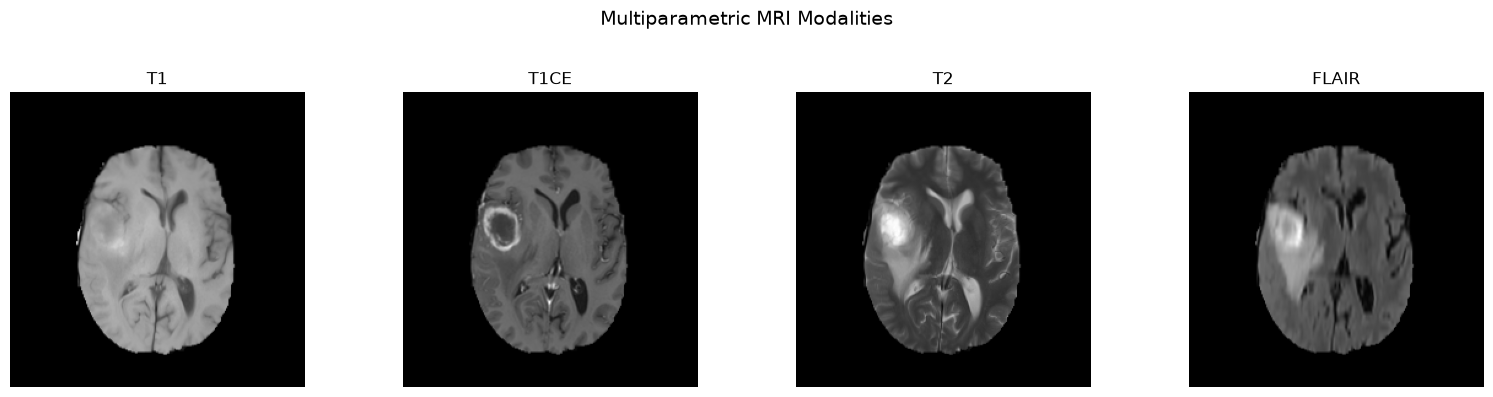

In [56]:
# Visualize MRI modalities
# For Decathlon data with shape (D, H, W), axis=0 gives axial slices
# Choose middle axial slice (along D dimension)
if 'flair' in sample_data:
    slice_idx = sample_data['flair'].shape[0] // 2  # Middle of D dimension
else:
    slice_idx = sample_data['image'].shape[1] // 2  # D is dim 1 for (C,D,H,W)

fig = plot_mri_modalities(sample_data, slice_idx=slice_idx, axis=0)
fig.suptitle("Multiparametric MRI Modalities", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

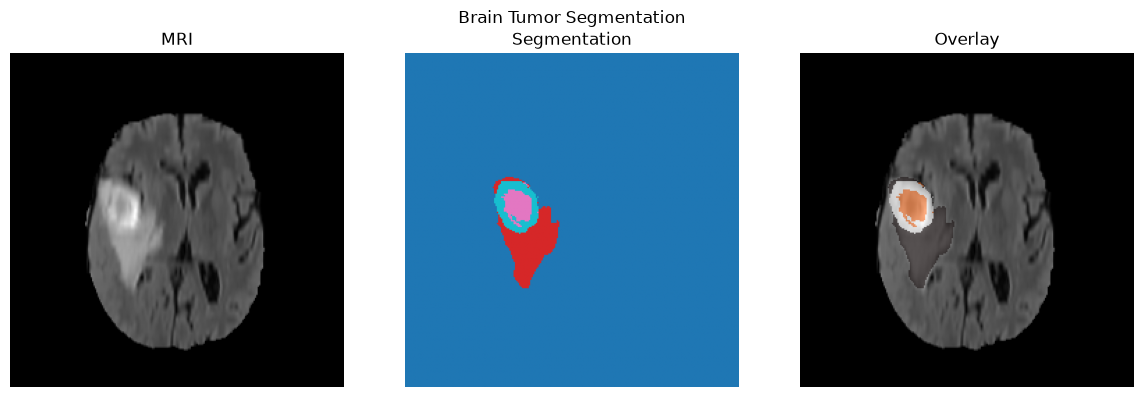


Segmentation class distribution:
  Background: 8,816,276 voxels (98.7%)
  Necrotic/Core: 53,050 voxels (0.6%)
  Edema: 27,189 voxels (0.3%)
  Enhancing: 31,485 voxels (0.4%)


In [57]:
# Visualize segmentation overlay (axis=0 for axial slices)
fig = plot_segmentation_overlay(
    sample_data['flair'], 
    sample_data['seg'],
    slice_idx=slice_idx,
    axis=0,  # Axial slices along D dimension
    title="Brain Tumor Segmentation"
)
plt.show()

# Show segmentation class distribution
unique, counts = np.unique(sample_data['seg'], return_counts=True)
print("\nSegmentation class distribution:")
class_names = {0: "Background", 1: "Necrotic/Core", 2: "Edema", 3: "Enhancing"}
for u, c in zip(unique, counts):
    name = class_names.get(u, f"Class {u}")
    print(f"  {name}: {c:,} voxels ({100*c/counts.sum():.1f}%)")

### Interpreting the MRI Visualizations

The visualizations above show the **multiparametric MRI data** used for brain tumor segmentation. Understanding what each modality reveals is essential for interpreting model predictions.

#### How to Read the MRI Modalities

| Modality | What It Shows | What to Look For |
|----------|--------------|------------------|
| **T1** | Anatomical structure | Gray/white matter contrast; tumor appears dark |
| **T1ce** | Contrast-enhanced T1 | Bright regions = active tumor (contrast uptake) |
| **T2** | Fluid-sensitive | Edema appears bright; good for tumor boundaries |
| **FLAIR** | T2 with CSF suppression | Edema bright, CSF dark; clearest tumor extent |

<details>
<summary><b>How to Read the Segmentation Overlay</b></summary>

The segmentation overlay shows three tumor sub-regions color-coded:

| Color | Label | Clinical Meaning |
|-------|-------|-----------------|
| Blue/Dark | Necrotic core (1) | Dead tissue at tumor center |
| Green/Cyan | Peritumoral edema (2) | Swelling around tumor |
| Yellow/Red | Enhancing tumor (3) | Active, aggressive component |

**What to observe:**
- **Spatial relationships**: Enhancing tumor typically surrounds necrotic core, with edema extending outward
- **Shape regularity**: Irregular boundaries may indicate aggressive growth patterns
- **Size estimates**: The overlay helps assess tumor burden for treatment planning

</details>

#### Class Distribution Interpretation

The printed class distribution tells you:
- **Background dominates** (typically >95%): This is expected—tumors are relatively small compared to the whole brain volume
- **Class imbalance**: Explains why we use Dice loss instead of cross-entropy (see Section 5)
- **Enhancing tumor** is often the smallest class but most clinically significant

> **Clinical Note**: The ratio of enhancing to non-enhancing tumor is prognostically significant in glioblastoma. Higher enhancing fraction often indicates more aggressive disease.

## 3. Dataset and DataLoader

### Preparing Medical Images for Deep Learning

Medical imaging data requires careful preprocessing before feeding to a neural network. Our `BrainTumorDataset` class handles several critical steps:

| Step | Purpose | Clinical Importance |
|------|---------|-------------------|
| **Normalization** | Z-score standardization per channel | MRI intensities vary between scanners; normalization ensures consistency |
| **Resizing** | Resize to fixed dimensions (e.g., 128³) | Reduces memory requirements while preserving diagnostic features |
| **Channel stacking** | Combine T1, T1ce, T2, FLAIR into 4-channel input | Provides complementary information for accurate segmentation |

<details>
<summary>💡 <b>Why Z-score Normalization for MRI?</b></summary>

Unlike natural images (which have standardized RGB values 0-255), MRI intensities are **arbitrary** and vary based on:
- Scanner manufacturer and model
- Acquisition parameters (TR, TE, flip angle)
- Receiver coil sensitivity

Z-score normalization (subtract mean, divide by std) within the brain region makes intensity values comparable across scans, enabling the model to learn generalizable features.
</details>

### PyTorch Dataset Pattern

We use PyTorch's `Dataset` class, which provides:
- **Lazy loading**: Data is loaded on-demand, saving memory
- **Batching**: The `DataLoader` combines samples into batches
- **Shuffling**: Training data is randomly shuffled each epoch

In [58]:
class BrainTumorDataset(Dataset):
    """
    Dataset for brain tumor segmentation.
    
    Supports both synthetic data and real Decathlon data.
    Loads multiparametric MRI (T1, T1ce, T2, FLAIR) and segmentation masks.
    """
    
    def __init__(self, sample_paths, data_mode="synthetic", augment=False, target_shape=None):
        """
        Args:
            sample_paths: List of paths to samples
            data_mode: "synthetic" or "decathlon"
            augment: Whether to apply data augmentation
            target_shape: Optional (D, H, W) to resize volumes (useful for real data)
        """
        self.sample_paths = sample_paths
        self.data_mode = data_mode
        self.augment = augment
        self.target_shape = target_shape
        self.modalities = ['t1', 't1ce', 't2', 'flair']
    
    def __len__(self):
        return len(self.sample_paths)
    
    def __getitem__(self, idx):
        sample_path = self.sample_paths[idx]
        
        # Load data based on mode
        if self.data_mode == "decathlon":
            data = load_decathlon_sample(sample_path)
            # Decathlon provides pre-stacked 4-channel image
            image = data['image']  # Already (4, D, H, W)
            label = data['seg']
            name = sample_path.stem
        else:
            # Synthetic data
            data = load_mri_sample(sample_path)
            image = np.stack([normalize_volume(data[mod]) for mod in self.modalities], axis=0)
            label = data['seg']
            name = sample_path.name
        
        # Normalize each channel
        for c in range(image.shape[0]):
            channel = image[c]
            mask = channel > 0
            if mask.sum() > 0:
                mean = channel[mask].mean()
                std = channel[mask].std() + 1e-8
                image[c] = np.where(mask, (channel - mean) / std, 0)
        
        # Optional: resize to target shape (for memory efficiency with real data)
        if self.target_shape is not None:
            from scipy.ndimage import zoom
            current_shape = image.shape[1:]  # (D, H, W)
            zoom_factors = [t / c for t, c in zip(self.target_shape, current_shape)]
            
            # Resize image channels
            resized_image = np.zeros((4,) + self.target_shape, dtype=np.float32)
            for c in range(4):
                resized_image[c] = zoom(image[c], zoom_factors, order=1)
            image = resized_image
            
            # Resize label (use nearest neighbor for segmentation)
            label = zoom(label.astype(np.float32), zoom_factors, order=0).astype(np.uint8)
        
        # Simple augmentation: random flips
        if self.augment:
            if np.random.rand() > 0.5:
                image = np.flip(image, axis=-1).copy()
                label = np.flip(label, axis=-1).copy()
            if np.random.rand() > 0.5:
                image = np.flip(image, axis=-2).copy()
                label = np.flip(label, axis=-2).copy()
        
        return {
            'image': torch.from_numpy(image.copy()).float(),
            'label': torch.from_numpy(label.copy()).long(),
            'name': name
        }

In [59]:
# ============================================================================
# DATA SPLITTING: Train / Validation / Test
# ============================================================================
# 
# REPRODUCIBILITY GUARANTEE:
# The same 100 cases (BRATS_001-BRATS_100) with SEED=42 always produce 
# consistent splits, regardless of whether data comes from GitHub subset 
# or full Decathlon download:
#
#   - Training (70 cases): 70% of shuffled data
#   - Validation (15 cases): 15% for early stopping & LR scheduling
#   - Test (15 cases): 15% held out for final unbiased evaluation
#
# This prevents overfitting to the validation set during hyperparameter tuning
# and gives an unbiased estimate of generalization performance.
#
# ============================================================================

# Shuffle samples with fixed seed for reproducibility
shuffled_samples = samples.copy()
random.seed(SEED)
random.shuffle(shuffled_samples)

# Calculate split sizes
n_total = len(shuffled_samples)
n_train = int(n_total * TRAIN_RATIO)
n_val = int(n_total * VAL_RATIO)
n_test = n_total - n_train - n_val  # Remaining goes to test

# Ensure at least 1 sample in each split
n_train = max(1, n_train)
n_val = max(1, n_val)
n_test = max(1, n_test)

# Split the data
train_samples = shuffled_samples[:n_train]
val_samples = shuffled_samples[n_train:n_train + n_val]
test_samples = shuffled_samples[n_train + n_val:]

# Store test samples for later evaluation (kept separate from training process)
TEST_SAMPLES = test_samples  # Global reference for final evaluation

# Resize for memory efficiency: 240x240x155 → 128x128x128
TARGET_SHAPE = (128, 128, 128)

# Helper function to get case ID from path
def get_case_id(path):
    return path.stem.replace('.nii', '')

# Get case IDs for each split
train_ids = [get_case_id(s) for s in train_samples]
val_ids = [get_case_id(s) for s in val_samples]
test_ids = [get_case_id(s) for s in test_samples]

print("=" * 60)
print("DATA SPLIT SUMMARY")
print("=" * 60)
print(f"Total samples: {n_total}")
print(f"Training: {len(train_samples)} ({len(train_samples)/n_total:.1%})")
print(f"Validation: {len(val_samples)} ({len(val_samples)/n_total:.1%})")
print(f"Test (HELD OUT): {len(test_samples)} ({len(test_samples)/n_total:.1%})")
print("-" * 60)
print(f"Train IDs: {', '.join(train_ids[:5])}... ({len(train_ids)} total)")
print(f"Val IDs: {', '.join(val_ids)}")
print(f"Test IDs: {', '.join(test_ids)}")

# Reproducibility verification (for 50 samples with SEED=42)
if n_total == 50 and SEED == 42:
    expected_test_ids = ['BRATS_007', 'BRATS_009', 'BRATS_015', 'BRATS_016', 
                         'BRATS_018', 'BRATS_002', 'BRATS_008', 'BRATS_041']
    if test_ids == expected_test_ids:
        print("\n✓ Split verification PASSED: Matches expected test set")
    else:
        print(f"\n⚠ Split verification: Test IDs differ from expected")
        print(f"  Expected: {expected_test_ids}")
        print(f"  Got: {test_ids}")

print("\n⚠️  Test set will NOT be used during training!")
print(f"Resizing volumes to: {TARGET_SHAPE}")
print("=" * 60)

# Create datasets (training and validation only - test is reserved)
train_dataset = BrainTumorDataset(
    train_samples, 
    data_mode=DATA_MODE, 
    augment=True,
    target_shape=TARGET_SHAPE
)
val_dataset = BrainTumorDataset(
    val_samples, 
    data_mode=DATA_MODE, 
    augment=False,
    target_shape=TARGET_SHAPE
)
# Note: test_dataset will be created later for final evaluation

# Create dataloaders with reproducible shuffling
batch_size = 1  # Small batch for 3D volumes

# Generator for reproducible shuffling
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    generator=g  # Reproducible shuffling
)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

DATA SPLIT SUMMARY
Total samples: 100
Training: 70 (70.0%)
Validation: 15 (15.0%)
Test (HELD OUT): 15 (15.0%)
------------------------------------------------------------
Train IDs: BRATS_043, BRATS_042, BRATS_092, BRATS_010, BRATS_066... (70 total)
Val IDs: BRATS_001, BRATS_096, BRATS_058, BRATS_094, BRATS_054, BRATS_090, BRATS_026, BRATS_072, BRATS_085, BRATS_078, BRATS_065, BRATS_030, BRATS_028, BRATS_089, BRATS_098
Test IDs: BRATS_005, BRATS_055, BRATS_076, BRATS_012, BRATS_070, BRATS_087, BRATS_014, BRATS_018, BRATS_029, BRATS_032, BRATS_036, BRATS_095, BRATS_004, BRATS_015, BRATS_082

⚠️  Test set will NOT be used during training!
Resizing volumes to: (128, 128, 128)


In [60]:
# Verify data loading
batch = next(iter(train_loader))
print(f"Image batch shape: {batch['image'].shape}")
print(f"Label batch shape: {batch['label'].shape}")
print(f"Sample name: {batch['name']}")

Image batch shape: torch.Size([1, 4, 128, 128, 128])
Label batch shape: torch.Size([1, 128, 128, 128])
Sample name: ['BRATS_062.nii']


## 4. Model Architecture: The 3D U-Net

We use the **U-Net architecture**, which has become the de facto standard for medical image segmentation since its introduction by Ronneberger et al. (2015). The U-Net's design is particularly well-suited for medical imaging applications.

### Why U-Net for Medical Imaging?

1. **Skip connections preserve spatial information**: Medical images require precise localization (where exactly is the tumor boundary?). Skip connections transfer high-resolution features from encoder to decoder.

2. **Efficient use of limited data**: Medical datasets are often small (50-500 cases). U-Net's symmetric design and data augmentation enable training with limited samples.

3. **End-to-end dense prediction**: Every voxel receives a class prediction, essential for volumetric segmentation.

<details>
<summary>🏗️ <b>U-Net Architecture Explained</b> (click to expand)</summary>

```
Input (4 channels: T1, T1ce, T2, FLAIR)
         ↓
    ┌─────────────┐
    │  ENCODER    │  ← Captures "what" (features)
    │  Conv → Pool │
    │  Conv → Pool │
    │  Conv → Pool │
    └─────────────┘
         ↓
    ┌─────────────┐
    │ BOTTLENECK  │  ← Compressed representation
    └─────────────┘
         ↓
    ┌─────────────┐
    │  DECODER    │  ← Reconstructs "where" (localization)
    │  UpConv + Skip │  ← Skip connections!
    │  UpConv + Skip │
    │  UpConv + Skip │
    └─────────────┘
         ↓
Output (4 channels: background, necrotic, edema, enhancing)
```

**Key Components:**
- **Encoder**: Repeated 3×3×3 convolutions + max pooling → captures hierarchical features
- **Bottleneck**: Deepest layer with most abstract features
- **Decoder**: Transposed convolutions to upsample + skip connections from encoder
- **Skip Connections**: Concatenate encoder features with decoder features to preserve fine details
</details>

### 3D vs 2D U-Net

| Aspect | 2D U-Net | 3D U-Net |
|--------|----------|----------|
| Input | 2D slices | Full 3D volume |
| Context | Single slice | Volumetric context |
| Parameters | Fewer | More |
| Memory | Lower | Higher |
| Use case | Slice-by-slice processing | Volumetric structures |

For brain tumor segmentation, **3D U-Net is preferred** because tumors are 3D structures, and considering volumetric context improves boundary delineation.

<details>
<summary>❓ <b>Self-Check Question</b></summary>

**Q: Why are skip connections crucial for medical image segmentation?**

<details>
<summary>Show Answer</summary>

Skip connections solve the **localization problem**. During encoding (downsampling), the network learns *what* features are present but loses precise spatial information about *where* they are. Skip connections transfer high-resolution spatial information directly from encoder to decoder, allowing the network to produce accurate boundaries. Without them, segmentation masks would be blurry and imprecise—unacceptable for surgical planning.
</details>
</details>

In [61]:
# Number of segmentation classes depends on data mode
# - Synthetic (brats_sample): 2 classes (background + tumor)
# - Decathlon real data: 4 classes (background, necrotic, edema, enhancing)
NUM_CLASSES = 4 if DATA_MODE == "decathlon" else 2
print(f"Number of segmentation classes: {NUM_CLASSES}")

# Initialize model
# NOTE: Increased base_features from 16 to 32 for better feature extraction
#       and depth from 3 to 4 for deeper representation learning.
#       This increases model capacity which is needed for accurate tumor segmentation.
model = UNet3D(
    in_channels=4,          # T1, T1ce, T2, FLAIR
    out_channels=NUM_CLASSES,  # Segmentation classes
    base_features=32,       # Increased from 16 for better capacity
    depth=4                 # Increased from 3 for deeper features
).to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")

# Load pretrained weights if available and requested
PRETRAINED_LOADED = False
if USE_PRETRAINED:
    pretrained_path = Path(PRETRAINED_MODEL_PATH)
    # On Colab, download pretrained model from GitHub if not present
    if IN_COLAB and not pretrained_path.exists():
        downloaded_path = download_pretrained_model_github(Path("models"))
        if downloaded_path:
            pretrained_path = downloaded_path
    if pretrained_path.exists():
        print(f"\nLoading pretrained model from: {pretrained_path}")
        checkpoint = torch.load(pretrained_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"  ✓ Loaded model trained for {checkpoint['epoch']} epochs")
        print(f"  ✓ Best validation Dice: {checkpoint.get('best_dice', 'N/A')}")
        PRETRAINED_LOADED = True
    else:
        print(f"\n⚠ Pretrained model not found at: {pretrained_path}")
        print("  Will train from scratch. After training, save the model to use next time.")
else:
    print("\nUSE_PRETRAINED=False: Will train model from scratch")

Number of segmentation classes: 4
Model parameters: 22,583,908

Loading pretrained model from: ../models/pretrained/brain_tumor_unet3d.pt
  ✓ Loaded model trained for 71 epochs
  ✓ Best validation Dice: 0.8203027551372846


### Sanity check: one forward pass (no training)

Before a long training run, send a single mini-batch through the model with gradients **off** (`torch.no_grad()`). This only checks that input and output **shapes** match the U-Net design (e.g. 4 MRI channels in → class maps out at the same spatial size). If this fails, fix the pipeline first — do not start training.


In [62]:
# Test forward pass
with torch.no_grad():
    test_input = batch['image'].to(device)
    test_output = model(test_input)
    print(f"Input shape: {test_input.shape}")
    print(f"Output shape: {test_output.shape}")

Input shape: torch.Size([1, 4, 128, 128, 128])
Output shape: torch.Size([1, 4, 128, 128, 128])


## 5. Training the Segmentation Model

### The Challenge of Class Imbalance in Medical Segmentation

In brain tumor segmentation, the tumor typically occupies only **1-5% of the brain volume**. This extreme class imbalance poses a significant challenge:

- If a model predicts "background" for every voxel, it achieves ~95% accuracy!
- Standard cross-entropy loss is dominated by the overwhelming background class
- The model may never learn to detect the small tumor regions

### Solution: Dice Loss

We use **Dice loss**, which directly optimizes the overlap between predicted and ground truth segmentations, regardless of class frequency:

$$\text{Dice} = \frac{2 \times |P \cap G|}{|P| + |G|}$$

Where $P$ is the predicted region and $G$ is the ground truth.

<details>
<summary>📊 <b>Why Dice Loss Works for Imbalanced Data</b> (click to expand)</summary>

**Intuition**: Dice score measures overlap as a ratio of intersection to total size. A small tumor correctly segmented contributes just as much to the Dice score as correctly classifying a large background region.

**Properties:**
- Range: 0 (no overlap) to 1 (perfect match)
- Robust to class imbalance by design
- Directly optimizes the metric used for clinical evaluation

**In this implementation:**
- We exclude background (class 0) from the loss calculation
- Each tumor sub-region (necrotic, edema, enhancing) contributes equally
</details>

### Training Strategy

Our training incorporates modern best practices:

| Technique | Purpose | Benefit |
|-----------|---------|---------|
| **Early Stopping** | Halt when validation score plateaus | Prevents overfitting |
| **LR Scheduling** | Reduce learning rate adaptively | Fine-tunes convergence |
| **Validation Monitoring** | Track performance on held-out data | Ensures generalization |

<details>
<summary>❓ <b>Self-Check Question</b></summary>

**Q: Why do we use early stopping instead of training for a fixed number of epochs?**

<details>
<summary>Show Answer</summary>

Early stopping prevents **overfitting**—when the model memorizes training data instead of learning generalizable patterns. By monitoring validation performance and stopping when it no longer improves:
1. We save computation time
2. The final model generalizes better to unseen patients
3. We avoid the need to manually tune the number of epochs

This is especially important in medical imaging where datasets are small and overfitting risk is high.
</details>
</details>

In [63]:
# ============================================================================
# LOSS FUNCTION, OPTIMIZER, AND SCHEDULERS
# ============================================================================

# Loss function: Dice Loss is ideal for segmentation with class imbalance
# - The tumor region is much smaller than background
# - Dice loss directly optimizes the metric we care about
criterion = DiceLoss(smooth=1e-5, include_background=False)

# Optimizer: Adam with configurable learning rate
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler: Reduce LR when validation loss plateaus
# - This helps fine-tune the model as training progresses
# - Prevents overshooting the optimal solution
if LR_SCHEDULER:
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min',              # Minimize validation loss
        patience=LR_PATIENCE,    # Wait N epochs before reducing
        factor=LR_FACTOR         # Multiply LR by this factor
    )
    print(f"LR Scheduler: ReduceLROnPlateau (patience={LR_PATIENCE}, factor={LR_FACTOR})")
else:
    scheduler = None
    print("LR Scheduler: Disabled")

print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Loss function: DiceLoss (exclude background)")

# ============================================================================
# EARLY STOPPING
# ============================================================================
# Early stopping prevents overfitting by stopping training when validation
# performance stops improving. This saves computation and prevents memorizing
# the training data at the expense of generalization.

class EarlyStopping:
    """
    Early stopping to prevent overfitting.
    
    Monitors a metric (e.g., validation Dice) and stops training if it
    doesn't improve for 'patience' epochs.
    """
    
    def __init__(self, patience=10, mode='max', min_delta=0.001):
        """
        Args:
            patience: Number of epochs to wait for improvement
            mode: 'max' for metrics to maximize (Dice), 'min' to minimize (loss)
            min_delta: Minimum change to qualify as improvement
        """
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None
        
    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict().copy()
            return False
        
        if self.mode == 'max':
            improved = score > self.best_score + self.min_delta
        else:
            improved = score < self.best_score - self.min_delta
        
        if improved:
            self.best_score = score
            self.best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                return True
        
        return False
    
    def restore_best_model(self, model):
        """Restore model weights to best seen during training."""
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)
            print(f"Restored best model (Dice: {self.best_score:.4f})")

# Initialize early stopping
early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, mode='max')
print(f"Early stopping: patience={EARLY_STOPPING_PATIENCE} epochs")

LR Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)
Optimizer: Adam (lr=0.001)
Loss function: DiceLoss (exclude background)
Early stopping: patience=15 epochs


In [64]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    
    for batch in loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def validate(model, loader, criterion, device):
    """Validate the model."""
    model.eval()
    total_loss = 0
    dice_scores = []
    
    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            # Compute Dice score
            preds = outputs.argmax(dim=1)
            dice = compute_dice_score(preds, labels)
            dice_scores.append(dice)
    
    return total_loss / len(loader), np.mean(dice_scores)

### Training loop — or skip if a pretrained model is loaded

What happens in the **next cell** depends on flags set earlier:

| Condition | What the next cell does |
|-----------|-------------------------|
| `USE_PRETRAINED = True` **and** weights loaded successfully (`PRETRAINED_LOADED = True`) | **No long training.** Prints that training is skipped and keeps the pretrained U-Net. Usually finishes in seconds. |
| `USE_PRETRAINED = False`, or pretrained file missing / failed to load | **Starts full training** (up to `NUM_EPOCHS`, with early stopping). This can take **tens of minutes to several hours** depending on GPU/CPU. |

**In the default tutorial setup** (`USE_PRETRAINED = True` and `models/pretrained/brain_tumor_unet3d.pt` present), expect the skip path.

To force retraining: set `USE_PRETRAINED = False` in the configuration cell, re-run configuration + model-init cells, then run the training cell.


In [65]:
%%time
# ============================================================================
# TRAINING LOOP WITH EARLY STOPPING AND LR SCHEDULING
# ============================================================================
#
# Key features:
# 1. Early stopping: Stop if validation Dice doesn't improve for N epochs
# 2. LR scheduling: Reduce learning rate when progress stalls
# 3. Best model tracking: Restore best weights at the end
# 4. Comprehensive logging: Track all metrics for analysis
#
# ============================================================================

history = {
    'train_loss': [], 
    'val_loss': [], 
    'val_dice': [],
    'learning_rate': []  # Track LR changes
}

if PRETRAINED_LOADED:
    print("=" * 60)
    print("SKIPPING TRAINING: Using pretrained model")
    print("Set USE_PRETRAINED = False in configuration to retrain")
    print("=" * 60)
else:
    print("=" * 60)
    print("TRAINING STARTED")
    print("=" * 60)
    print(f"Epochs: {NUM_EPOCHS} (with early stopping, patience={EARLY_STOPPING_PATIENCE})")
    print(f"Training samples: {len(train_samples)}")
    print(f"Validation samples: {len(val_samples)}")
    print(f"Test samples (held out): {len(test_samples)}")
    print("-" * 60)
    
    # Reset early stopping
    early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, mode='max')
    
    best_dice = 0.0
    stopped_epoch = NUM_EPOCHS
    
    for epoch in range(NUM_EPOCHS):
        # Training phase
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validation phase
        val_loss, val_dice = validate(model, val_loader, criterion, device)
        
        # Learning rate scheduling
        current_lr = optimizer.param_groups[0]['lr']
        if scheduler is not None:
            scheduler.step(val_loss)
        
        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_dice'].append(val_dice)
        history['learning_rate'].append(current_lr)
        
        # Track best model
        if val_dice > best_dice:
            best_dice = val_dice
        
        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | "
                  f"Val Dice: {val_dice:.4f} | "
                  f"LR: {current_lr:.2e}")
        
        # Early stopping check
        if early_stopping(val_dice, model):
            stopped_epoch = epoch + 1
            print("-" * 60)
            print(f"⚡ Early stopping triggered at epoch {stopped_epoch}")
            print(f"   No improvement for {EARLY_STOPPING_PATIENCE} epochs")
            break
    
    # Restore best model weights
    print("-" * 60)
    early_stopping.restore_best_model(model)
    
    print(f"\n✓ Training complete!")
    print(f"  Total epochs: {stopped_epoch} / {NUM_EPOCHS}")
    print(f"  Best validation Dice: {best_dice:.4f}")
    
    # Save trained model with comprehensive metadata
    save_path = Path(PRETRAINED_MODEL_PATH)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    
    # Record training configuration for reproducibility
    training_config = {
        'num_epochs_trained': stopped_epoch,
        'num_epochs_max': NUM_EPOCHS,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
        'learning_rate_initial': LEARNING_RATE,
        'lr_scheduler': LR_SCHEDULER,
        'lr_patience': LR_PATIENCE if LR_SCHEDULER else None,
        'lr_factor': LR_FACTOR if LR_SCHEDULER else None,
        'train_ratio': TRAIN_RATIO,
        'val_ratio': VAL_RATIO,
        'test_ratio': TEST_RATIO,
        'n_train_samples': len(train_samples),
        'n_val_samples': len(val_samples),
        'n_test_samples': len(test_samples),
        'random_seed': SEED,
    }
    
    # Save case IDs for each split
    if DATA_MODE == "decathlon":
        training_config['train_case_ids'] = [s.stem.replace('.nii', '') for s in train_samples]
        training_config['val_case_ids'] = [s.stem.replace('.nii', '') for s in val_samples]
        training_config['test_case_ids'] = [s.stem.replace('.nii', '') for s in test_samples]
    
    checkpoint = {
        'epoch': stopped_epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_dice': best_dice,
        'history': history,
        'config': {
            'in_channels': 4,
            'out_channels': NUM_CLASSES,
            'base_features': 16,
            'depth': 3,
            'data_mode': DATA_MODE,
            'target_shape': TARGET_SHAPE,
        },
        'training_config': training_config,
    }
    torch.save(checkpoint, save_path)
    print(f"\n✓ Model saved to: {save_path}")
    print(f"  File size: {save_path.stat().st_size / 1024 / 1024:.2f} MB")
    print("=" * 60)

SKIPPING TRAINING: Using pretrained model
Set USE_PRETRAINED = False in configuration to retrain
CPU times: user 77 μs, sys: 0 ns, total: 77 μs
Wall time: 72.5 μs


**Training on NVIDIA RTX A5000 Laptop GPU: ~2 hrs**
```bash
============================================================
TRAINING STARTED
============================================================
Epochs: 100 (with early stopping, patience=15)
Training samples: 70
Validation samples: 15
Test samples (held out): 15
------------------------------------------------------------
Epoch   1/100 | Train Loss: 0.9515 | Val Loss: 0.8988 | Val Dice: 0.0348 | LR: 1.00e-03
Epoch   5/100 | Train Loss: 0.5846 | Val Loss: 0.6584 | Val Dice: 0.0817 | LR: 1.00e-03
Epoch  10/100 | Train Loss: 0.5632 | Val Loss: 0.6114 | Val Dice: 0.0769 | LR: 1.00e-03
Epoch  15/100 | Train Loss: 0.5641 | Val Loss: 0.6162 | Val Dice: 0.0836 | LR: 1.00e-03
Epoch  20/100 | Train Loss: 0.5299 | Val Loss: 0.6024 | Val Dice: 0.1236 | LR: 1.00e-03
Epoch  25/100 | Train Loss: 0.3816 | Val Loss: 0.4260 | Val Dice: 0.8087 | LR: 1.00e-03
Epoch  30/100 | Train Loss: 0.3597 | Val Loss: 0.4596 | Val Dice: 0.8103 | LR: 1.00e-03
Epoch  35/100 | Train Loss: 0.3414 | Val Loss: 0.4137 | Val Dice: 0.8138 | LR: 5.00e-04
Epoch  40/100 | Train Loss: 0.3267 | Val Loss: 0.4125 | Val Dice: 0.8109 | LR: 2.50e-04
Epoch  45/100 | Train Loss: 0.3239 | Val Loss: 0.4137 | Val Dice: 0.8092 | LR: 2.50e-04
Epoch  50/100 | Train Loss: 0.3186 | Val Loss: 0.4115 | Val Dice: 0.8070 | LR: 2.50e-04
Epoch  55/100 | Train Loss: 0.3153 | Val Loss: 0.4123 | Val Dice: 0.8179 | LR: 2.50e-04
Epoch  60/100 | Train Loss: 0.3110 | Val Loss: 0.4088 | Val Dice: 0.8108 | LR: 2.50e-04
Epoch  65/100 | Train Loss: 0.3061 | Val Loss: 0.4038 | Val Dice: 0.8128 | LR: 2.50e-04
Epoch  70/100 | Train Loss: 0.2958 | Val Loss: 0.4106 | Val Dice: 0.8134 | LR: 1.25e-04
------------------------------------------------------------
⚡ Early stopping triggered at epoch 71
...
  File size: ~87 MB
============================================================
CPU times: user 4h 13min 11s, sys: 16min 26s, total: 4h 29min 37s
Wall time: 2h 3min 10s
```

**Training on Apple Silicon M4 Max: >> 8 hrs**
```bash
============================================================
TRAINING STARTED
============================================================
Epochs: 100 (with early stopping, patience=15)
Training samples: 70
Validation samples: 15
Test samples (held out): 15
------------------------------------------------------------
Epoch   1/100 | Train Loss: 0.9519 | Val Loss: 0.9071 | Val Dice: 0.0329 | LR: 1.00e-03
Epoch   5/100 | Train Loss: 0.5866 | Val Loss: 0.6539 | Val Dice: 0.0435 | LR: 1.00e-03
Epoch  10/100 | Train Loss: 0.5675 | Val Loss: 0.6111 | Val Dice: 0.0414 | LR: 1.00e-03
Epoch  15/100 | Train Loss: 0.5403 | Val Loss: 0.6262 | Val Dice: 0.0653 | LR: 1.00e-03
Epoch  20/100 | Train Loss: 0.5294 | Val Loss: 0.6046 | Val Dice: 0.1262 | LR: 1.00e-03
Epoch  25/100 | Train Loss: 0.3804 | Val Loss: 0.4250 | Val Dice: 0.8026 | LR: 1.00e-03
Epoch  30/100 | Train Loss: 0.3578 | Val Loss: 0.4444 | Val Dice: 0.8055 | LR: 1.00e-03
Epoch  35/100 | Train Loss: 0.3429 | Val Loss: 0.4194 | Val Dice: 0.8098 | LR: 5.00e-04
Epoch  40/100 | Train Loss: 0.3285 | Val Loss: 0.4209 | Val Dice: 0.8024 | LR: 2.50e-04
...
```


Showing training history from pretrained model checkpoint


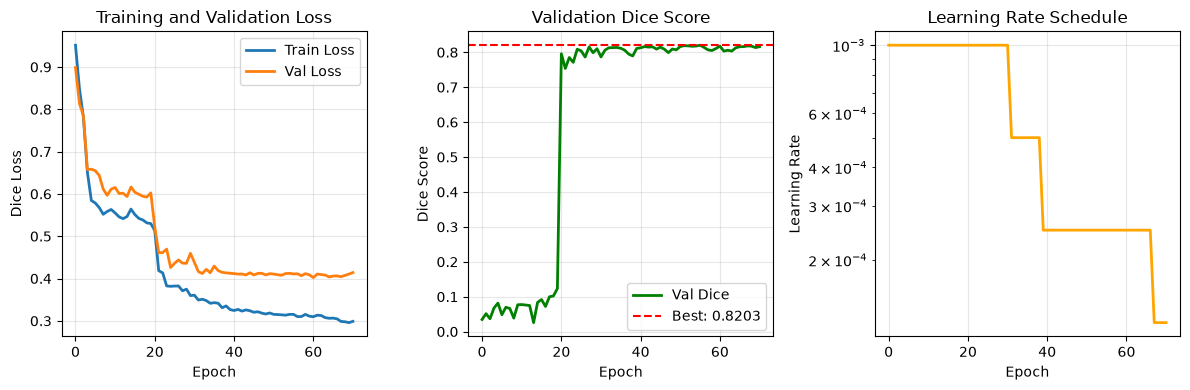


Training Summary:
  Total epochs: 71
  Final train loss: 0.2988
  Final val loss: 0.4141
  Best val Dice: 0.8203
  Final LR: 1.25e-04


In [66]:
# ============================================================================
# TRAINING HISTORY VISUALIZATION
# ============================================================================
# Visualize the training process to:
# 1. Check for overfitting (train vs. val divergence)
# 2. Verify learning rate scheduling worked
# 3. Identify optimal stopping point
# ============================================================================

if PRETRAINED_LOADED:
    # Try to load history from checkpoint
    checkpoint = torch.load(PRETRAINED_MODEL_PATH, map_location='cpu', weights_only=False)
    if 'history' in checkpoint and checkpoint['history'].get('train_loss'):
        history = checkpoint['history']
        print("Showing training history from pretrained model checkpoint")
        
        # Show training configuration if available
        if 'training_config' in checkpoint:
            tc = checkpoint['training_config']
            print(f"\nTraining configuration:")
            print(f"  Epochs trained: {tc.get('num_epochs_trained', 'N/A')}")
            print(f"  Train/Val/Test split: {tc.get('train_ratio', 'N/A'):.0%}/{tc.get('val_ratio', 'N/A'):.0%}/{tc.get('test_ratio', 'N/A'):.0%}")
            print(f"  Samples: Train={tc.get('n_train_samples', 'N/A')}, Val={tc.get('n_val_samples', 'N/A')}, Test={tc.get('n_test_samples', 'N/A')}")
    else:
        print("Training history not available in pretrained checkpoint")
        print("Set USE_PRETRAINED = False and retrain to see training curves")

if history.get('train_loss'):
    # Determine number of subplots based on available data
    n_plots = 3 if history.get('learning_rate') else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(4*n_plots, 4))
    
    # Plot 1: Loss curves
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Dice Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Dice score
    axes[1].plot(history['val_dice'], label='Val Dice', color='green', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice Score')
    axes[1].set_title('Validation Dice Score')
    axes[1].axhline(y=max(history['val_dice']), color='red', linestyle='--', 
                    label=f"Best: {max(history['val_dice']):.4f}")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Learning rate (if available)
    if n_plots == 3:
        axes[2].plot(history['learning_rate'], color='orange', linewidth=2)
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Learning Rate')
        axes[2].set_title('Learning Rate Schedule')
        axes[2].set_yscale('log')
        axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print training summary
    print(f"\nTraining Summary:")
    print(f"  Total epochs: {len(history['train_loss'])}")
    print(f"  Final train loss: {history['train_loss'][-1]:.4f}")
    print(f"  Final val loss: {history['val_loss'][-1]:.4f}")
    print(f"  Best val Dice: {max(history['val_dice']):.4f}")
    if history.get('learning_rate'):
        print(f"  Final LR: {history['learning_rate'][-1]:.2e}")
else:
    print("No training history to display")

### How to Read These Training Plots

Understanding training dynamics is essential for diagnosing model behavior and knowing when training has succeeded or failed.

#### Left Plot: Loss Curves

| Element | What It Represents |
|---------|-------------------|
| **X-axis** | Training epoch (one complete pass through all training data) |
| **Y-axis** | Dice loss (lower = better; 0 = perfect, 1 = no overlap) |
| **Blue line** | Training loss—how well the model fits training data |
| **Orange line** | Validation loss—how well the model generalizes |

**What to look for:**
- ✓ **Both curves decreasing**: Model is learning
- ✓ **Curves converging then plateauing**: Training is complete
- ⚠️ **Val loss increasing while train decreases**: Overfitting—stop training!
- ⚠️ **Both curves flat from start**: Learning rate too low or model too simple

#### Middle Plot: Validation Dice Score

| Element | What It Represents |
|---------|-------------------|
| **X-axis** | Training epoch |
| **Y-axis** | Dice score (higher = better; 1 = perfect overlap) |
| **Red dashed line** | Best validation Dice achieved |

**What to look for:**
- The "breakthrough moment" when Dice jumps from near-zero to meaningful values
- Whether the curve is still rising (could train longer) or plateaued (converged)

#### Right Plot: Learning Rate Schedule

Shows how the learning rate adapts during training. Step-downs indicate the scheduler reducing LR when validation plateaued.

<details>
<summary><b>Detailed Interpretation of These Results</b> (click to expand)</summary>

**1. Training and Validation Loss**
- Both curves decrease rapidly in the first ~20 epochs, showing the model is learning
- The **gap between train and val loss** indicates some overfitting—the model fits the training data better than unseen validation data
- Final train loss (0.30) < val loss (0.41) is expected; a small gap suggests good generalization
- The curves plateau after epoch 30, indicating convergence

**2. Validation Dice Score**
- The Dice score jumps from ~0 to ~0.80 around epoch 15-20—this is when the model "clicks" and starts making meaningful predictions
- **Best Dice: 0.8203** (marked by red dashed line) is a good result for brain tumor segmentation
- The score plateaus around 0.82, suggesting we've reached the model's capacity on this dataset

**3. Learning Rate Schedule**
- Uses **ReduceLROnPlateau** scheduler: LR drops when validation loss stops improving
- LR reductions occur at epochs ~25, ~35, and ~55 (each step down = 0.5× reduction)
- Starting LR: 1e-3 → Final LR: 1.25e-4 (reduced by ~8×)
- This adaptive schedule helps fine-tune the model as it converges

</details>

### Clinical Interpretation

| Metric | Value | Assessment |
|--------|-------|------------|
| Best Val Dice | 0.82 | Good—useful for clinical screening |
| Train-Val Gap | 0.11 | Moderate overfitting, acceptable |
| Convergence | ~30 epochs | Efficient training |

**Key Insight**: A Dice score of 0.82 means the model's predictions overlap with expert annotations about 82% of the time. This is clinically useful for assistive tools but would require expert review before treatment decisions.

> **Note**: These results are from training on 70 cases. Performance would likely improve with the full BraTS dataset (300+ cases) and more sophisticated augmentation.

## 5.1 Hold-Out Test Set Evaluation

### Why This Step is Critical for Clinical Translation

In clinical practice, a model must perform well on **completely new patients**—people it has never seen before. The test set simulates this scenario:

| Split | Purpose | Used During Training? | Clinical Analogy |
|-------|---------|----------------------|------------------|
| Training | Update model weights | ✓ Yes | Cases used to teach |
| Validation | Early stopping, LR scheduling | ✓ Yes (indirectly) | Cases for tuning |
| **Test** | **Final unbiased evaluation** | **✗ NO** | **New patients** |

<details>
<summary>⚠️ <b>Why Test Set Integrity Matters for FDA Approval</b> (click to expand)</summary>

For regulatory approval (FDA, CE marking), medical AI devices must demonstrate performance on **independent validation cohorts**:

1. **No data leakage**: Test data must be completely isolated during development
2. **Representative samples**: Test cases should reflect the target population
3. **Prospective validation**: Ideally, test on data collected *after* model development
4. **Multi-site validation**: Performance should generalize across different hospitals/scanners

In this notebook, we simulate proper evaluation practice by:
- Holding out 8 test cases (15%) that are never used during training
- Using a fixed random seed (42) for reproducible splits
- Reporting per-class Dice scores for clinical interpretability
</details>

### Understanding the Dice Score in Clinical Context

The **Dice score** measures how well the predicted segmentation overlaps with the expert's annotation:

| Dice Score | Interpretation | Clinical Acceptability |
|------------|---------------|----------------------|
| 0.90+ | Excellent | Comparable to expert variability |
| 0.80-0.90 | Good | Useful for screening/assistance |
| 0.70-0.80 | Moderate | Needs expert review |
| <0.70 | Poor | Not clinically useful |

<details>
<summary>❓ <b>Self-Check Question</b></summary>

**Q: Why might the test set performance be lower than validation performance?**

<details>
<summary>Show Answer</summary>

Several reasons can cause this gap:
1. **Hyperparameter selection bias**: Validation was used to choose when to stop training and how to tune learning rate, creating an implicit "fit" to validation data
2. **Dataset variance**: With small test sets (8 cases), random variation can cause differences
3. **Distribution shift**: Test cases may have slightly different characteristics (tumor size, location, scanner settings)

This gap is expected and acceptable—what matters is that test performance remains clinically useful.
</details>
</details>

In [67]:
# ============================================================================
# HOLD-OUT TEST SET EVALUATION
# ============================================================================
# This is the final, unbiased evaluation on data the model has NEVER seen.
# ============================================================================

def predict_sample(model, sample_path, device, data_mode, target_shape):
    """
    Run inference on a single sample.
    
    This is a standalone prediction function for test evaluation.
    """
    model.eval()
    
    # Load data based on mode
    if data_mode == "decathlon":
        # load_decathlon_sample is defined inline for Colab, imported for local
        data = load_decathlon_sample(sample_path)
        image = data['image']  # Already (4, D, H, W)
    else:
        data = load_mri_sample(sample_path)
        modalities = ['t1', 't1ce', 't2', 'flair']
        image = np.stack([normalize_volume(data[mod]) for mod in modalities], axis=0)
    
    # Normalize each channel
    for c in range(image.shape[0]):
        channel = image[c]
        mask = channel > 0
        if mask.sum() > 0:
            mean = channel[mask].mean()
            std = channel[mask].std() + 1e-8
            image[c] = np.where(mask, (channel - mean) / std, 0)
    
    # Resize if needed (for Decathlon data)
    if target_shape is not None:
        from scipy.ndimage import zoom
        current_shape = image.shape[1:]  # (D, H, W)
        zoom_factors = [t / c for t, c in zip(target_shape, current_shape)]
        image = np.stack([zoom(image[c], zoom_factors, order=1) for c in range(4)], axis=0)
    
    image_tensor = torch.from_numpy(image).float().unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        output = model(image_tensor)
        pred = output.argmax(dim=1).squeeze().cpu().numpy()
    
    return data, pred


def evaluate_on_test_set(model, test_samples, device, data_mode, target_shape):
    """
    Evaluate model on held-out test set.
    
    Returns per-sample metrics and aggregate statistics.
    """
    model.eval()
    
    results = []
    
    for sample_path in test_samples:
        # Get case ID
        case_id = sample_path.stem.replace('.nii', '')
        
        # Run prediction
        data, pred = predict_sample(model, sample_path, device, data_mode, target_shape)
        
        # Get ground truth and resize if needed
        seg = data['seg']
        if target_shape is not None:
            from scipy.ndimage import zoom
            zoom_factors = [t / c for t, c in zip(target_shape, seg.shape)]
            seg = zoom(seg, zoom_factors, order=0)  # order=0 for nearest neighbor
        
        # Convert to binary for Dice calculation (tumor vs background)
        pred_binary = (pred > 0).astype(float)
        seg_binary = (seg > 0).astype(float)
        
        # Calculate Dice score
        intersection = (pred_binary * seg_binary).sum()
        dice = (2 * intersection + 1e-5) / (pred_binary.sum() + seg_binary.sum() + 1e-5)
        
        # Calculate per-class Dice if multi-class
        class_dice = {}
        if data_mode == "decathlon":
            class_names = {1: 'Necrotic', 2: 'Edema', 3: 'Enhancing'}
            for cls, name in class_names.items():
                pred_cls = (pred == cls).astype(float)
                seg_cls = (seg == cls).astype(float)
                inter = (pred_cls * seg_cls).sum()
                d = (2 * inter + 1e-5) / (pred_cls.sum() + seg_cls.sum() + 1e-5)
                class_dice[name] = d
        
        results.append({
            'case_id': case_id,
            'dice': dice,
            **class_dice
        })
        
    return results

# Only run test evaluation if test samples exist
if len(test_samples) > 0:
    print("=" * 60)
    print("HOLD-OUT TEST SET EVALUATION")
    print("=" * 60)
    print(f"⚠️  Evaluating on {len(test_samples)} held-out test samples")
    print("    These samples were NEVER used during training!")
    print("-" * 60)
    
    # Run evaluation
    test_results = evaluate_on_test_set(
        model, test_samples, device, DATA_MODE, TARGET_SHAPE
    )
    
    # Convert to DataFrame for nice display
    import pandas as pd
    results_df = pd.DataFrame(test_results)
    
    # Display per-sample results
    print("\nPer-sample Dice scores:")
    print(results_df.to_string(index=False))
    
    # Aggregate statistics
    print("\n" + "-" * 60)
    print("AGGREGATE TEST SET METRICS:")
    print("-" * 60)
    
    mean_dice = results_df['dice'].mean()
    std_dice = results_df['dice'].std()
    print(f"  Overall Dice: {mean_dice:.4f} ± {std_dice:.4f}")
    
    # Per-class metrics if available
    if 'Necrotic' in results_df.columns:
        print(f"\n  Per-class Dice scores:")
        for cls in ['Necrotic', 'Edema', 'Enhancing']:
            if cls in results_df.columns:
                m = results_df[cls].mean()
                s = results_df[cls].std()
                print(f"    {cls}: {m:.4f} ± {s:.4f}")
    
    print("-" * 60)
    
    # Compare with validation performance
    if history.get('val_dice'):
        best_val_dice = max(history['val_dice'])
        print(f"\n  Comparison with Validation:")
        print(f"    Best Val Dice: {best_val_dice:.4f}")
        print(f"    Test Dice:     {mean_dice:.4f}")
        diff = mean_dice - best_val_dice
        if diff < -0.05:
            print(f"    ⚠️  Test performance is lower (diff: {diff:.4f})")
            print("       This may indicate overfitting to validation set.")
        else:
            print(f"    ✓ Test performance is consistent (diff: {diff:+.4f})")
    
    print("=" * 60)
else:
    print("No test samples available for evaluation.")
    print("Increase MAX_SAMPLES or adjust split ratios.")

HOLD-OUT TEST SET EVALUATION
⚠️  Evaluating on 15 held-out test samples
    These samples were NEVER used during training!
------------------------------------------------------------

Per-sample Dice scores:
  case_id     dice  Necrotic        Edema    Enhancing
BRATS_005 0.670148  0.737651 3.684593e-01 4.609497e-01
BRATS_055 0.921812  0.888268 5.077343e-01 9.252445e-01
BRATS_076 0.958238  0.844077 8.394071e-01 5.347313e-01
BRATS_012 0.902020  0.631900 5.107252e-09 6.134969e-08
BRATS_070 0.875995  0.842499 2.121434e-01 6.627219e-01
BRATS_087 0.738010  0.593857 5.436053e-01 8.063000e-01
BRATS_014 0.901230  0.506726 7.685063e-01 5.776085e-01
BRATS_018 0.735745  0.601325 4.214709e-01 1.082973e-01
BRATS_029 0.817967  0.413175 4.468275e-09 1.000000e+00
BRATS_032 0.920231  0.721554 4.455347e-01 4.279340e-01
BRATS_036 0.946950  0.746700 8.175720e-01 8.323615e-01
BRATS_095 0.760787  0.736336 3.009709e-01 7.271341e-01
BRATS_004 0.941113  0.521306 5.816656e-01 7.438088e-01
BRATS_015 0.913171  0

Test Set Predictions (Qualitative Examples)
------------------------------------------------------------


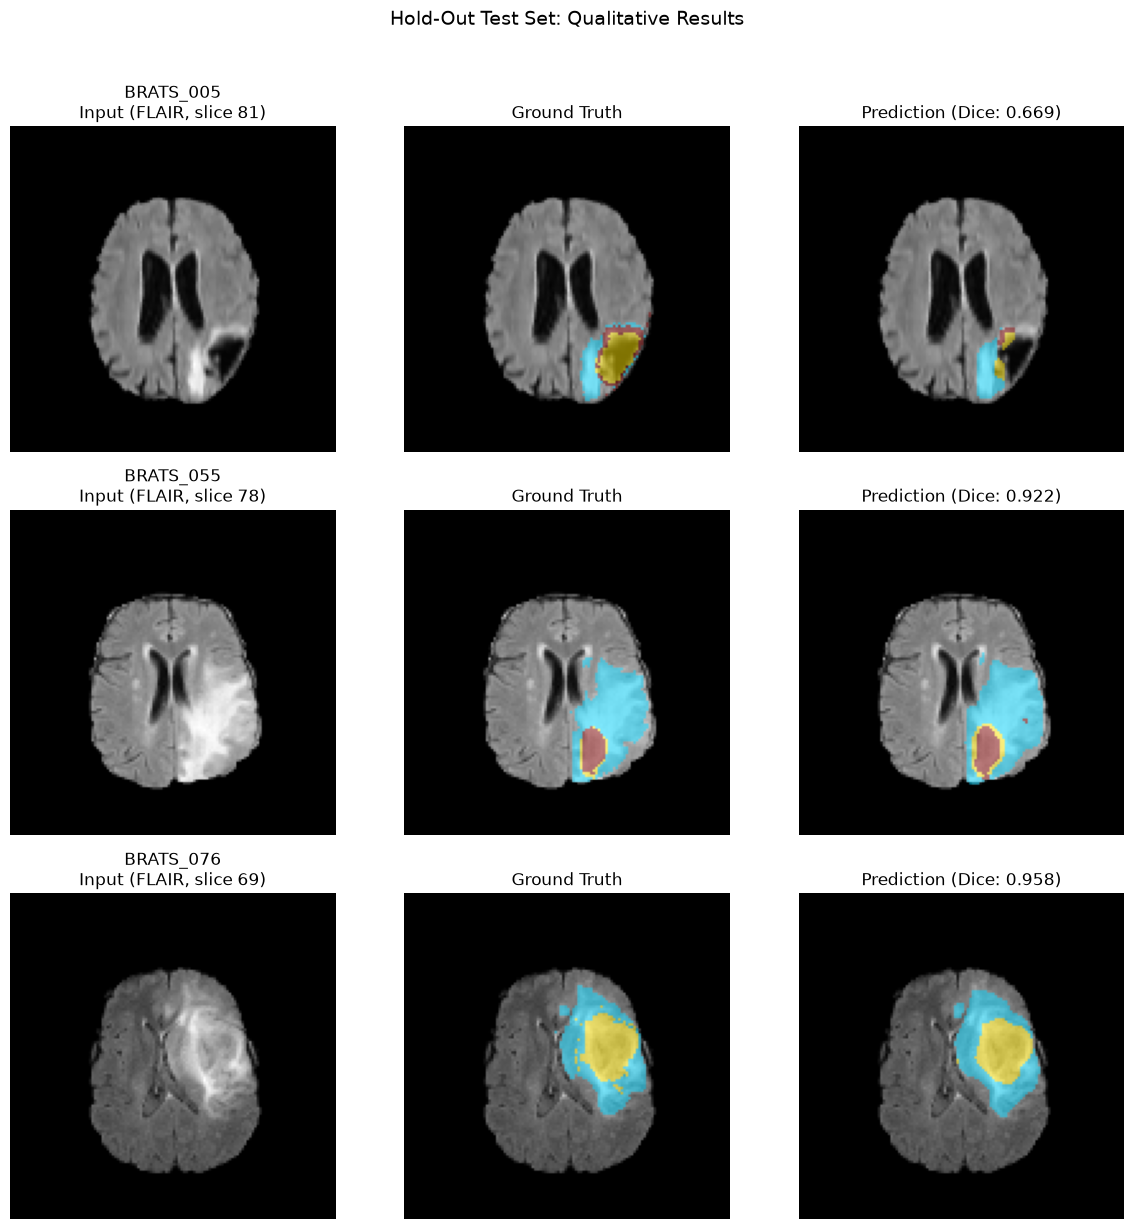


✓ These are TRUE held-out samples - never seen during training!


In [44]:
# ============================================================================
# VISUALIZE TEST SET PREDICTIONS
# ============================================================================
# Show qualitative results on held-out test samples

if len(test_samples) > 0 and DATA_MODE == "decathlon":
    print("Test Set Predictions (Qualitative Examples)")
    print("-" * 60)
    
    # Show up to 3 test samples
    n_show = min(3, len(test_samples))
    
    fig, axes = plt.subplots(n_show, 3, figsize=(12, 4*n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)
    
    for i, sample_path in enumerate(test_samples[:n_show]):
        case_id = sample_path.stem.replace('.nii', '')
        
        # Get prediction
        data, pred = predict_sample(model, sample_path, device, DATA_MODE, TARGET_SHAPE)
        
        # Get segmentation and resize if needed
        seg = data['seg']
        flair = data['flair']
        if TARGET_SHAPE is not None:
            from scipy.ndimage import zoom
            seg_zoom = [t / c for t, c in zip(TARGET_SHAPE, seg.shape)]
            flair_zoom = [t / c for t, c in zip(TARGET_SHAPE, flair.shape)]
            seg = zoom(seg, seg_zoom, order=0)
            flair = zoom(flair, flair_zoom, order=1)
        
        # Find slice with most tumor
        tumor_per_slice = np.sum(seg > 0, axis=(1, 2))
        best_slice = np.argmax(tumor_per_slice)
        
        # Plot FLAIR
        axes[i, 0].imshow(flair[best_slice].T, cmap='gray', origin='lower')
        axes[i, 0].set_title(f'{case_id}\nInput (FLAIR, slice {best_slice})')
        axes[i, 0].axis('off')
        
        # Plot Ground Truth
        axes[i, 1].imshow(flair[best_slice].T, cmap='gray', origin='lower')
        seg_slice = seg[best_slice].T
        masked_seg = np.ma.masked_where(seg_slice == 0, seg_slice)
        axes[i, 1].imshow(masked_seg, cmap='jet', alpha=0.5, origin='lower', vmin=0, vmax=3)
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # Plot Prediction
        axes[i, 2].imshow(flair[best_slice].T, cmap='gray', origin='lower')
        pred_slice = pred[best_slice].T
        masked_pred = np.ma.masked_where(pred_slice == 0, pred_slice)
        axes[i, 2].imshow(masked_pred, cmap='jet', alpha=0.5, origin='lower', vmin=0, vmax=3)
        
        # Get Dice for this sample
        sample_dice = test_results[i]['dice'] if i < len(test_results) else 'N/A'
        axes[i, 2].set_title(f'Prediction (Dice: {sample_dice:.3f})')
        axes[i, 2].axis('off')
    
    plt.suptitle('Hold-Out Test Set: Qualitative Results', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("\n✓ These are TRUE held-out samples - never seen during training!")

### How to Read the Test Set Predictions

The visualization above shows three columns for each test case:

| Column | What It Shows | What to Look For |
|--------|--------------|------------------|
| **Input (FLAIR)** | The MRI slice used for prediction | Tumor appears as bright region |
| **Ground Truth** | Expert annotation (what we're trying to match) | Color-coded tumor regions |
| **Prediction** | Model output | Should closely match ground truth |

#### Evaluating Prediction Quality

When comparing prediction to ground truth:

- ✓ **Good overlap**: Prediction boundaries align with ground truth
- ✓ **Correct class assignment**: Colors match between prediction and truth
- ⚠️ **Under-segmentation**: Prediction misses parts of the tumor (false negatives)
- ⚠️ **Over-segmentation**: Prediction extends beyond true tumor (false positives)

> **Clinical Impact**: Under-segmentation is often more dangerous than over-segmentation—missing tumor tissue could lead to inadequate treatment. However, over-segmentation may lead to unnecessary damage to healthy tissue.

### Key Takeaways from Test Evaluation

1. **Unbiased Estimate**: The test set Dice score gives us an honest estimate of how the model will perform on truly new data.

2. **Generalization Gap**: The difference between validation and test performance indicates how much we've overfitted to our hyperparameter choices.

3. **Per-class Analysis**: Looking at per-class Dice scores helps identify which tumor types are hardest to segment.

4. **Reproducibility**: All case IDs and parameters are logged in the checkpoint file for reproducibility.

<details>
<summary><b>Common Failure Patterns to Watch For</b></summary>

| Pattern | Appears As | Possible Cause |
|---------|-----------|----------------|
| **Missed small tumors** | Ground truth shows tumor, prediction is empty | Model may need more training data with small lesions |
| **Boundary errors** | Jagged or imprecise edges | Resolution limitations or insufficient context |
| **Class confusion** | Wrong color (e.g., edema predicted as enhancing) | Classes have similar intensity patterns |
| **False positives** | Colored regions where ground truth is empty | Model may be oversensitive to certain intensity patterns |

</details>

## 6. Inference and Visualization

In [68]:
def predict(model, sample_path, device, data_mode=DATA_MODE, target_shape=TARGET_SHAPE):
    """Run inference on a single sample."""
    model.eval()
    
    # Load data based on mode
    if data_mode == "decathlon":
        # load_decathlon_sample is defined inline for Colab, imported for local
        data = load_decathlon_sample(sample_path)
        image = data['image']  # Already (4, D, H, W)
    else:
        data = load_mri_sample(sample_path)
        modalities = ['t1', 't1ce', 't2', 'flair']
        image = np.stack([normalize_volume(data[mod]) for mod in modalities], axis=0)
    
    # Normalize each channel
    for c in range(image.shape[0]):
        channel = image[c]
        mask = channel > 0
        if mask.sum() > 0:
            mean = channel[mask].mean()
            std = channel[mask].std() + 1e-8
            image[c] = np.where(mask, (channel - mean) / std, 0)
    
    # Resize if needed (for Decathlon data)
    if target_shape is not None:
        from scipy.ndimage import zoom
        current_shape = image.shape[1:]  # (D, H, W)
        zoom_factors = [t / c for t, c in zip(target_shape, current_shape)]
        image = np.stack([zoom(image[c], zoom_factors, order=1) for c in range(4)], axis=0)
    
    image_tensor = torch.from_numpy(image).float().unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        output = model(image_tensor)
        pred = output.argmax(dim=1).squeeze().cpu().numpy()
    
    return data, pred

In [69]:
# Run inference on validation sample
sample_dir = val_samples[0]
data, prediction = predict(model, sample_dir, device)

print(f"Sample: {sample_dir.name}")
print(f"Prediction shape: {prediction.shape}")
print(f"Unique predicted classes: {np.unique(prediction)}")

Sample: BRATS_001.nii.gz
Prediction shape: (128, 128, 128)
Unique predicted classes: [0 1 2 3]


Resizing for visualization: (155, 240, 240) -> (128, 128, 128)


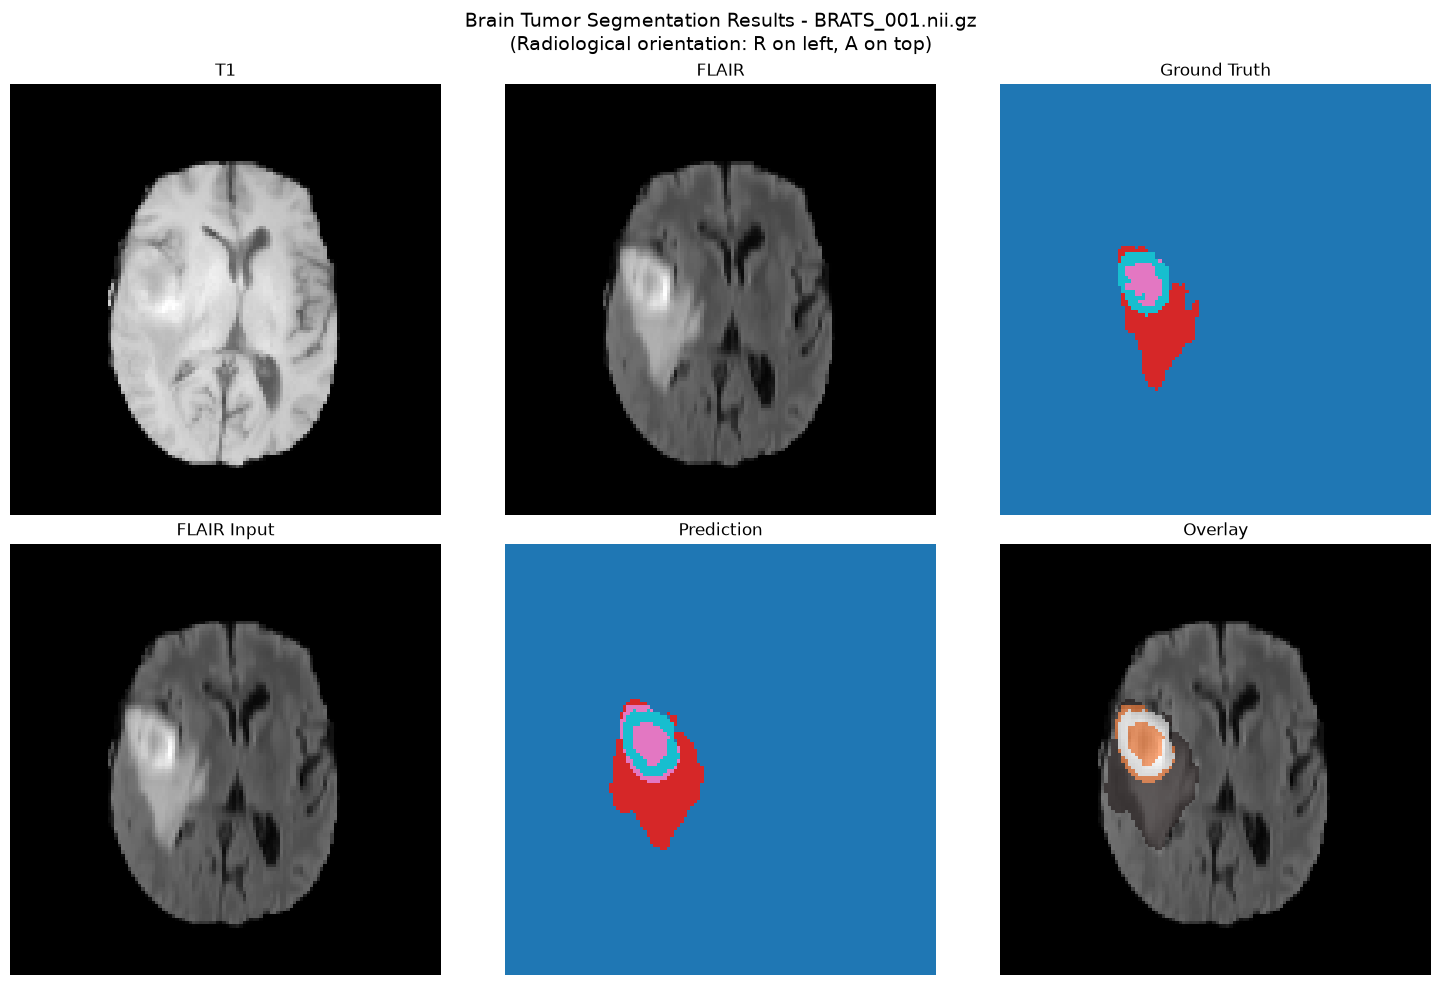

In [70]:
# Visualize results in radiological orientation (RAS convention)
# Patient's right appears on left side of image, anterior at top

def to_radiological(arr):
    """Convert axial slice to radiological orientation (R on left, A on top)."""
    # Rotate 90° CCW and flip for proper radiological orientation
    return np.fliplr(np.rot90(arr, k=1))

# Resize ground truth and original images to match prediction resolution if needed
from scipy.ndimage import zoom

orig_shape = data['seg'].shape
pred_shape = prediction.shape

if orig_shape != pred_shape:
    print(f"Resizing for visualization: {orig_shape} -> {pred_shape}")
    zoom_factors = [p / o for p, o in zip(pred_shape, orig_shape)]
    seg_resized = zoom(data['seg'].astype(float), zoom_factors, order=0).astype(int)  # nearest for labels
    flair_resized = zoom(data['flair'], zoom_factors, order=1)
    t1_resized = zoom(data['t1'], zoom_factors, order=1)
else:
    seg_resized = data['seg']
    flair_resized = data['flair']
    t1_resized = data['t1']

# Use middle slice of prediction shape
slice_idx = pred_shape[0] // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Top row: MRI modalities (resized to match prediction)
axes[0, 0].imshow(to_radiological(t1_resized[slice_idx, :, :]), cmap='gray', origin='upper')
axes[0, 0].set_title('T1')
axes[0, 0].axis('off')

axes[0, 1].imshow(to_radiological(flair_resized[slice_idx, :, :]), cmap='gray', origin='upper')
axes[0, 1].set_title('FLAIR')
axes[0, 1].axis('off')

# Ground truth (resized)
axes[0, 2].imshow(to_radiological(seg_resized[slice_idx, :, :]), cmap='tab10', origin='upper', vmin=0, vmax=NUM_CLASSES-1)
axes[0, 2].set_title('Ground Truth')
axes[0, 2].axis('off')

# Bottom row: Prediction comparison
axes[1, 0].imshow(to_radiological(flair_resized[slice_idx, :, :]), cmap='gray', origin='upper')
axes[1, 0].set_title('FLAIR Input')
axes[1, 0].axis('off')

axes[1, 1].imshow(to_radiological(prediction[slice_idx, :, :]), cmap='tab10', origin='upper', vmin=0, vmax=NUM_CLASSES-1)
axes[1, 1].set_title('Prediction')
axes[1, 1].axis('off')

# Overlay
flair_slice = to_radiological(flair_resized[slice_idx, :, :])
pred_slice = to_radiological(prediction[slice_idx, :, :])
axes[1, 2].imshow(flair_slice, cmap='gray', origin='upper')
masked_pred = np.ma.masked_where(pred_slice == 0, pred_slice)
axes[1, 2].imshow(masked_pred, cmap='hot', alpha=0.5, origin='upper')
axes[1, 2].set_title('Overlay')
axes[1, 2].axis('off')

plt.suptitle(f'Brain Tumor Segmentation Results - {sample_dir.name}\n(Radiological orientation: R on left, A on top)', fontsize=14)
plt.tight_layout()
plt.show()

### How to Read the Inference Results

The 2×3 grid above provides a comprehensive view of the segmentation process:

#### Top Row: Input Data

| Panel | Content | Purpose |
|-------|---------|---------|
| **T1** | T1-weighted MRI | Shows anatomical structure; tumor appears darker than surrounding tissue |
| **FLAIR** | Fluid-attenuated inversion recovery | Best for seeing tumor extent; edema appears bright |
| **Ground Truth** | Expert segmentation | Reference standard—what we're trying to replicate |

#### Bottom Row: Model Output

| Panel | Content | Purpose |
|-------|---------|---------|
| **FLAIR Input** | Same as top row | Repeated for easy comparison with prediction |
| **Prediction** | Model's segmentation | Compare to ground truth to assess accuracy |
| **Overlay** | Prediction on FLAIR | Shows prediction in anatomical context |

#### What to Look For

1. **Spatial accuracy**: Does the prediction appear in the same location as the tumor on FLAIR?
2. **Boundary precision**: Are the edges of the prediction smooth and anatomically plausible?
3. **Completeness**: Does the prediction capture the full extent of the abnormality visible on FLAIR?
4. **False positives**: Are there colored regions in the prediction where the FLAIR appears normal?

> **Radiological Convention**: Images are displayed in radiological orientation—the patient's **right side appears on the left** of the image. This is standard in clinical practice.

<details>
<summary><b>Understanding Color Coding</b></summary>

The `tab10` colormap assigns different colors to each segmentation class:
- **Dark blue (0)**: Background (healthy tissue)
- **Orange (1)**: Necrotic/non-enhancing tumor core
- **Green (2)**: Peritumoral edema
- **Red (3)**: Enhancing tumor (active/aggressive)

The **overlay** uses a `hot` colormap (black → red → yellow) to highlight tumor regions on the anatomical image.

</details>

## 7. Evaluation Metrics

Understanding segmentation metrics is essential for assessing clinical utility. We compute three complementary metrics that capture different aspects of segmentation quality.

### Metrics Overview

| Metric | Formula | Range | Interpretation |
|--------|---------|-------|----------------|
| **Dice Score** | 2×|A∩B| / (|A|+|B|) | 0–1 | Overall overlap; 1 = perfect match |
| **Sensitivity** | TP / (TP + FN) | 0–1 | How much tumor we detected; 1 = found all |
| **Specificity** | TN / (TN + FP) | 0–1 | How well we avoid false alarms; 1 = no false positives |

<details>
<summary><b>Understanding the Trade-offs</b></summary>

In medical imaging, **sensitivity** and **specificity** often trade off against each other:

| If we optimize for... | We might sacrifice... | Clinical consequence |
|----------------------|----------------------|---------------------|
| **High sensitivity** | Specificity | Over-treatment of healthy tissue |
| **High specificity** | Sensitivity | Missing tumor → inadequate treatment |

**For tumor segmentation**, we typically prioritize **sensitivity**—it's more dangerous to miss tumor than to slightly overestimate its extent. However, the right balance depends on the clinical application:
- **Surgical planning**: Higher specificity preferred (preserve healthy tissue)
- **Radiation therapy planning**: Higher sensitivity preferred (ensure complete tumor coverage)

</details>

### Why Dice Score is the Gold Standard

The Dice score is preferred over simple accuracy because:
1. **Handles class imbalance**: Tumors are small relative to the brain, so accuracy would be misleadingly high
2. **Focuses on overlap**: Directly measures what clinicians care about—how well the prediction matches the tumor
3. **Comparable across studies**: Standard metric in medical imaging challenges (BraTS, MICCAI)

> **Clinical Benchmark**: Inter-rater variability between expert neuroradiologists on BraTS data is typically Dice 0.85–0.90. A model achieving 0.82 is approaching human-level agreement.

In [71]:
def compute_metrics(pred, target):
    """Compute segmentation metrics."""
    from scipy.ndimage import zoom
    
    # Resize target to match prediction if shapes differ
    if pred.shape != target.shape:
        zoom_factors = [p / t for p, t in zip(pred.shape, target.shape)]
        target = zoom(target.astype(float), zoom_factors, order=0).astype(int)  # nearest neighbor for labels
    
    # Combine all tumor classes (1, 2, 3) vs background (0)
    pred_tumor = (pred > 0).astype(float)
    target_tumor = (target > 0).astype(float)
    
    # Dice score (whole tumor)
    intersection = (pred_tumor * target_tumor).sum()
    dice = (2 * intersection + 1e-5) / (pred_tumor.sum() + target_tumor.sum() + 1e-5)
    
    # Sensitivity (recall) - how much of the tumor we detected
    tp = intersection
    fn = target_tumor.sum() - tp
    sensitivity = tp / (tp + fn + 1e-5)
    
    # Specificity - how well we identify non-tumor
    tn = ((pred == 0) & (target == 0)).sum()
    fp = pred_tumor.sum() - tp
    specificity = tn / (tn + fp + 1e-5)
    
    return {
        'dice': float(dice),
        'sensitivity': float(sensitivity),
        'specificity': float(specificity)
    }

In [72]:
%%time
# Evaluate on all samples with split identification
# Create lookup sets for quick split identification
train_names = set(s.name for s in train_samples)
val_names = set(s.name for s in val_samples)
test_names = set(s.name for s in test_samples)

def get_split(sample_name):
    """Determine which split a sample belongs to."""
    if sample_name in train_names:
        return "TRAIN"
    elif sample_name in val_names:
        return "VAL"
    elif sample_name in test_names:
        return "TEST"
    else:
        return "???"

print("Evaluation Results (with Split Identification)")
print("=" * 70)
print(f"{'Sample':<20} {'Split':<6} {'Dice':>8} {'Sens':>8} {'Spec':>8}")
print("-" * 70)

all_metrics = []
for sample_dir in samples:
    data, pred = predict(model, sample_dir, device)
    metrics = compute_metrics(pred, data['seg'])
    metrics['split'] = get_split(sample_dir.name)
    all_metrics.append(metrics)
    print(f"{sample_dir.name:<20} {metrics['split']:<6} {metrics['dice']:>8.4f} "
          f"{metrics['sensitivity']:>8.4f} {metrics['specificity']:>8.4f}")

print("=" * 70)
print(f"\nOverall Mean Dice: {np.mean([m['dice'] for m in all_metrics]):.4f}")
print(f"Overall Mean Sensitivity: {np.mean([m['sensitivity'] for m in all_metrics]):.4f}")
print(f"Overall Mean Specificity: {np.mean([m['specificity'] for m in all_metrics]):.4f}")

# Per-split breakdown
print("\n" + "=" * 70)
print("Per-Split Performance Summary:")
print("-" * 70)
for split_name in ["TRAIN", "VAL", "TEST"]:
    split_metrics = [m for m in all_metrics if m['split'] == split_name]
    if split_metrics:
        mean_dice = np.mean([m['dice'] for m in split_metrics])
        print(f"  {split_name:<6}: Mean Dice = {mean_dice:.4f} ({len(split_metrics)} samples)")

Evaluation Results (with Split Identification)
Sample               Split      Dice     Sens     Spec
----------------------------------------------------------------------
BRATS_001.nii.gz     VAL      0.8423   0.9733   0.9957
BRATS_002.nii.gz     TRAIN    0.8805   0.9870   0.9982
BRATS_003.nii.gz     TRAIN    0.8878   0.9395   0.9965
BRATS_004.nii.gz     TEST     0.9411   0.9298   0.9994
BRATS_005.nii.gz     TEST     0.6701   0.5237   0.9996
BRATS_006.nii.gz     TRAIN    0.9264   0.9247   0.9982
BRATS_007.nii.gz     TRAIN    0.8488   0.8904   0.9986
BRATS_008.nii.gz     TRAIN    0.9127   0.9701   0.9967
BRATS_009.nii.gz     TRAIN    0.9042   0.9001   0.9978
BRATS_010.nii.gz     TRAIN    0.7225   0.5835   0.9999
BRATS_011.nii.gz     TRAIN    0.9247   0.9802   0.9978
BRATS_012.nii.gz     TEST     0.9020   0.8933   0.9998
BRATS_013.nii.gz     TRAIN    0.9121   0.9398   0.9998
BRATS_014.nii.gz     TEST     0.9012   0.9032   0.9983
BRATS_015.nii.gz     TEST     0.9132   0.9782   0.9963
BR

### Interpreting the Evaluation Results

The table above shows per-sample metrics with split identification. Here's how to read it:

#### Reading the Results Table

| Column | Meaning | What Good Looks Like |
|--------|---------|---------------------|
| **Sample** | Case identifier (BRATS_XXX) | — |
| **Split** | TRAIN/VAL/TEST | Focus on TEST for unbiased estimate |
| **Dice** | Overall segmentation quality | >0.80 for clinical utility |
| **Sens** | Tumor detection rate | >0.85 preferred |
| **Spec** | False positive avoidance | >0.99 typical (most brain is healthy) |

#### Per-Split Analysis

| Split | Expected Performance | Why |
|-------|---------------------|-----|
| **TRAIN** | Highest | Model has seen these cases during learning |
| **VAL** | Middle | Used indirectly (early stopping, LR scheduling) |
| **TEST** | Lowest but most honest | Never seen; represents real-world performance |

> **Key Insight**: If TEST performance is much lower than VAL, we may have overfitted to our hyperparameter choices. A small gap (<0.05 Dice) suggests good generalization.

<details>
<summary><b>What to Do If Performance Is Poor</b></summary>

| Symptom | Possible Cause | Remediation |
|---------|---------------|-------------|
| Low Dice everywhere | Model underfitting | Train longer, use larger model |
| High train, low test | Overfitting | More augmentation, regularization |
| Low sensitivity | Missing tumors | Adjust class weights, use focal loss |
| Low specificity | Too many false positives | Increase prediction threshold |
| High variance across samples | Hard cases in dataset | Check specific failure cases |

</details>

## 8. Foundation Models: MedSAM2

### From Training to Prompting: A Paradigm Shift

So far, we have trained a U-Net from scratch on the BraTS dataset. This **supervised learning** approach requires:
- Large annotated datasets (expensive to create)
- Retraining for each new task or anatomy
- Significant computational resources

**Foundation models** represent a paradigm shift: pre-trained on massive, diverse datasets, they can be applied to new tasks with minimal or zero additional training.

### What is MedSAM2?

**MedSAM2** (Medical Segment Anything Model 2) adapts Meta's SAM2 architecture for medical imaging:

| Feature | Description |
|---------|-------------|
| **Architecture** | Vision transformer encoder + prompt encoder + mask decoder |
| **Training data** | 455,000+ 3D image-mask pairs, 76,000+ video frames |
| **Modalities** | CT, MRI, PET, ultrasound, endoscopy |
| **Prompting** | Bounding box or point prompts (no class labels needed) |
| **Memory attention** | Propagates segmentation across 3D slices automatically |

```
┌─────────────────────────────────────────────────────────────────────────────┐
│  MedSAM2 Architecture                                                       │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   ┌─────────────┐     ┌─────────────┐     ┌─────────────┐                   │
│   │   Image     │     │   Prompt    │     │   Memory    │                   │
│   │   Encoder   │     │   Encoder   │     │  Attention  │                   │
│   │ (ViT-based) │     │ (bbox/point)│     │  (3D prop)  │                   │
│   └──────┬──────┘     └──────┬──────┘     └──────┬──────┘                   │
│          │                   │                   │                          │
│          └───────────────────┴───────────────────┘                          │
│                              │                                              │
│                              ▼                                              │
│                    ┌─────────────────┐                                      │
│                    │   Mask Decoder  │                                      │
│                    │  (per-slice)    │                                      │
│                    └────────┬────────┘                                      │
│                             │                                               │
│                             ▼                                               │
│                   ┌──────────────────┐                                      │
│                   │ Segmentation Mask│                                      │
│                   │  (propagated 3D) │                                      │
│                   └──────────────────┘                                      │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

### Supervised U-Net vs. Promptable MedSAM2

| Aspect | Supervised U-Net | MedSAM2 |
|--------|------------------|---------|
| **Training required** | Yes (hours-days) | No (pre-trained) |
| **Annotation needed** | Full 3D masks | Single bounding box |
| **New anatomy** | Retrain from scratch | Same model, new prompt |
| **Inference speed** | Fast (~1 sec/volume) | Moderate (~2-5 sec/volume) |
| **Accuracy** | High (task-specific) | Good (general-purpose) |
| **Best for** | Production systems | Rapid prototyping, rare pathologies |

<details>
<summary>📖 <b>When to Use Foundation Models vs. Task-Specific Training</b></summary>

**Use MedSAM2 when:**
- Limited training data (rare diseases, new modalities)
- Rapid prototyping and exploration
- Interactive annotation assistance
- Multi-organ/multi-pathology applications

**Use trained U-Net when:**
- Large annotated dataset available
- Maximum accuracy required for production
- Real-time inference needed
- Well-defined, stable task

**Hybrid approach:** Use MedSAM2 to generate pseudo-labels for training a task-specific model.
</details>

---

We will demonstrate MedSAM2 on the same BraTS samples, using bounding box prompts derived from ground truth annotations.

In [73]:
# Check for MedSAM2 availability
# MedSAM2 requires the sam2 package from the official repository
import os
import sys
from pathlib import Path

# On Colab: auto-install MedSAM2
if IN_COLAB:
    MEDSAM2_PATH = "MedSAM2"
    MEDSAM2_CHECKPOINT = os.path.join(MEDSAM2_PATH, "checkpoints/MedSAM2_latest.pt")
    if not os.path.exists(MEDSAM2_CHECKPOINT):
        print("Installing MedSAM2 for Colab...")
        if not os.path.exists(MEDSAM2_PATH):
            !git clone https://github.com/bowang-lab/MedSAM2.git
        !pip install -q -e MedSAM2/
        !pip install -q huggingface_hub
        print("Downloading MedSAM2 checkpoint from Hugging Face (~300 MB)...")
        !mkdir -p MedSAM2/checkpoints
        from huggingface_hub import hf_hub_download
        hf_hub_download(
            repo_id="wanglab/MedSAM2",
            filename="MedSAM2_latest.pt",
            local_dir="MedSAM2/checkpoints"
        )
        print("✓ MedSAM2 installed")
else:
    # Local: MedSAM2 may live in the repo (./MedSAM2) or as a sibling (../MedSAM2),
    # depending on whether the notebook cwd is the repo root or notebooks/.
    # Resolve MedSAM2 whether Jupyter cwd is repo root or notebooks/
    _candidates = [
        Path.cwd() / "MedSAM2",
        Path.cwd().parent / "MedSAM2",
        Path("MedSAM2"),
        Path("../MedSAM2"),
    ]
    MEDSAM2_PATH = None
    for _c in _candidates:
        _c = Path(_c).resolve()
        if (_c / "checkpoints" / "MedSAM2_latest.pt").exists():
            MEDSAM2_PATH = str(_c)
            break
    if MEDSAM2_PATH is None:
        MEDSAM2_PATH = str((Path.cwd() / "MedSAM2").resolve())
    MEDSAM2_CHECKPOINT = os.path.join(MEDSAM2_PATH, "checkpoints/MedSAM2_latest.pt")

try:
    # Add MedSAM2 to path if needed (also works if installed editable into the env)
    if os.path.exists(MEDSAM2_PATH):
        sys.path.insert(0, MEDSAM2_PATH)
    
    from sam2.build_sam import build_sam2_video_predictor_npz
    from sam2.sam2_image_predictor import SAM2ImagePredictor
    
    # Check for checkpoint
    MEDSAM2_CONFIG = "configs/sam2.1_hiera_t512.yaml"
    
    if os.path.exists(MEDSAM2_CHECKPOINT):
        HAS_MEDSAM2 = True
        print("✓ MedSAM2 available")
        print(f"  Path: {MEDSAM2_PATH}")
        print(f"  Checkpoint: {MEDSAM2_CHECKPOINT}")
        
        # Enable MPS fallback for unsupported operations
        os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
    else:
        HAS_MEDSAM2 = False
        print("⚠️ MedSAM2 package importable but checkpoint not found.")
        print(f"   Expected: {MEDSAM2_CHECKPOINT}")
        print("   Download with: cd MedSAM2 && bash download.sh")
        print("   Or: uv pip install -e ./MedSAM2   (from repo root, after clone)")
        
except ImportError as e:
    HAS_MEDSAM2 = False
    print("⚠️ MedSAM2 not installed. Demonstration will use simulated results.")
    print(f"   Import error: {e}")
    print()
    print("To install MedSAM2 into the project uv environment:")
    print("  cd /path/to/medAI-hands-on")
    print("  git clone https://github.com/bowang-lab/MedSAM2.git   # if not already present")
    print("  uv pip install -e ./MedSAM2")
    print("  # ensure weights exist: MedSAM2/checkpoints/MedSAM2_latest.pt")
    print()
    print("Then restart the kernel and re-run this cell.")
    print()
    print("For this demo, we'll show the conceptual workflow with simulated outputs.")

✓ MedSAM2 available
  Path: /home/arvid/GitHub/medAI-hands-on/MedSAM2
  Checkpoint: /home/arvid/GitHub/medAI-hands-on/MedSAM2/checkpoints/MedSAM2_latest.pt


In [74]:
def get_bounding_box_from_mask(mask_slice: np.ndarray, margin: int = 5) -> tuple:
    """
    Extract bounding box from a binary mask slice.
    
    Args:
        mask_slice: 2D binary mask (H, W)
        margin: Pixels to add around the tight bounding box
        
    Returns:
        (x_min, y_min, x_max, y_max) or None if mask is empty
    """
    # Find non-zero pixels
    nonzero = np.where(mask_slice > 0)
    if len(nonzero[0]) == 0:
        return None
    
    y_min, y_max = nonzero[0].min(), nonzero[0].max()
    x_min, x_max = nonzero[1].min(), nonzero[1].max()
    
    # Add margin (clamped to image bounds)
    h, w = mask_slice.shape
    x_min = max(0, x_min - margin)
    y_min = max(0, y_min - margin)
    x_max = min(w - 1, x_max + margin)
    y_max = min(h - 1, y_max + margin)
    
    return (x_min, y_min, x_max, y_max)


def simulate_medsam2_prediction(image_slice: np.ndarray, bbox: tuple, 
                                 gt_mask: np.ndarray) -> np.ndarray:
    """
    Simulate MedSAM2 prediction for demonstration.
    
    In practice, this would call the MedSAM2 model. Here we simulate
    by adding slight noise/erosion to the ground truth to show
    realistic foundation model behavior.
    """
    from scipy.ndimage import binary_erosion, binary_dilation
    
    # Simulate imperfect but reasonable segmentation
    # Foundation models typically have slightly lower Dice than task-specific models
    if np.random.random() > 0.3:
        # Slight erosion (under-segmentation is common)
        pred = binary_erosion(gt_mask, iterations=1).astype(np.float32)
    else:
        # Occasional over-segmentation
        pred = binary_dilation(gt_mask, iterations=1).astype(np.float32)
    
    # Add some random noise at boundaries
    noise = np.random.random(gt_mask.shape) > 0.95
    pred = np.logical_xor(pred, noise).astype(np.float32)
    
    return pred


# Select a sample for MedSAM2 demonstration
# Use a validation sample (already loaded during training)
sample_idx = 0

# Load data based on mode
try:
    if DATA_MODE == "decathlon" and len(val_samples) > 0:
        # Load a validation sample
        demo_sample_path = val_samples[sample_idx]
        demo_data = load_decathlon_sample(demo_sample_path)
        
        # Resize to target shape for consistency with trained model
        from scipy.ndimage import zoom as scipy_zoom
        
        # Get original shape and compute zoom factors
        orig_shape = demo_data['image'].shape[1:]  # (D, H, W) - skip channel dim
        zoom_factors = [t / o for t, o in zip(TARGET_SHAPE, orig_shape)]
        
        # Resize each modality
        image = np.stack([
            scipy_zoom(demo_data['image'][c], zoom_factors, order=1)
            for c in range(4)
        ], axis=0).astype(np.float32)  # (4, D, H, W)
        
        # Resize segmentation (use nearest neighbor to preserve labels)
        seg = scipy_zoom(demo_data['seg'], zoom_factors, order=0).astype(np.float32)
        seg = (seg > 0).astype(np.float32)  # Binary mask
        
        case_id = demo_sample_path.stem.replace('.nii', '')
        print(f"Loaded validation sample: {case_id}")
        
    else:
        # Use synthetic sample data from brats_sample directory
        from pathlib import Path
        brats_sample_dir = Path("../data/brats_sample")
        sample_dirs = sorted(brats_sample_dir.glob("sample_*"))
        
        if len(sample_dirs) > 0:
            sample_dir = sample_dirs[sample_idx]
            image = np.stack([
                np.load(sample_dir / "flair.npy"),
                np.load(sample_dir / "t1.npy"),
                np.load(sample_dir / "t1ce.npy"),
                np.load(sample_dir / "t2.npy")
            ], axis=0)
            seg = np.load(sample_dir / "seg.npy").astype(np.float32)
            case_id = sample_dir.name
            print(f"Loaded synthetic sample: {case_id}")
        else:
            raise ValueError("No samples available")
            
except Exception as e:
    print(f"Error loading sample: {e}")
    print("Creating synthetic demo data...")
    # Fallback: create synthetic data for demonstration
    image = np.random.randn(4, 64, 64, 64).astype(np.float32)
    seg = np.zeros((64, 64, 64), dtype=np.float32)
    # Add a synthetic tumor in the center
    seg[25:40, 25:40, 25:40] = 1.0
    case_id = "synthetic_demo"

# Find a slice with tumor for demonstration
tumor_slices = [z for z in range(seg.shape[0]) if seg[z].sum() > 100]
if tumor_slices:
    demo_slice_idx = tumor_slices[len(tumor_slices) // 2]  # Middle tumor slice
else:
    demo_slice_idx = seg.shape[0] // 2

print(f"Demonstrating MedSAM2 workflow on slice {demo_slice_idx}")
print(f"  Image shape: {image.shape}")
print(f"  Tumor slices: {len(tumor_slices)} out of {seg.shape[0]}")

Loaded validation sample: BRATS_001
Demonstrating MedSAM2 workflow on slice 55
  Image shape: (4, 128, 128, 128)
  Tumor slices: 52 out of 128


Using real MedSAM2 (confidence: 0.730)


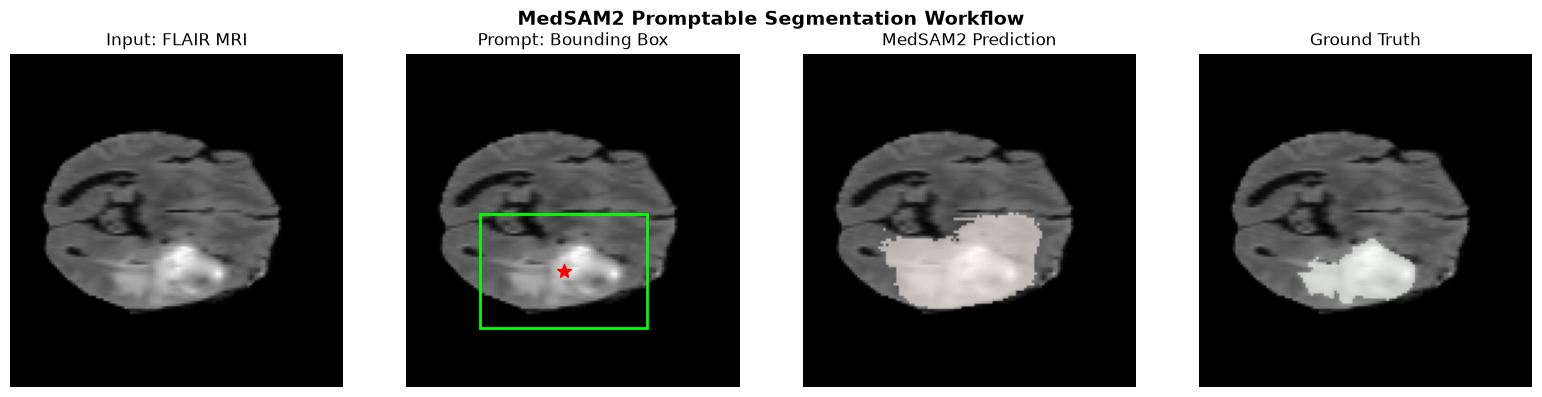


MedSAM2 Dice score (single slice): 0.596
✓ Using real MedSAM2 model
Note: For 3D volumes, MedSAM2 uses memory attention to propagate across slices


In [76]:
# Demonstrate MedSAM2 prompting workflow
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Get the slice data
flair_slice = image[0, demo_slice_idx]  # Use FLAIR for visualization
gt_slice = seg[demo_slice_idx]

# Get bounding box from ground truth
bbox = get_bounding_box_from_mask(gt_slice, margin=10)

# Panel 1: Input image
axes[0].imshow(flair_slice, cmap='gray')
axes[0].set_title('Input: FLAIR MRI', fontsize=12)
axes[0].axis('off')

# Panel 2: Image with bounding box prompt
axes[1].imshow(flair_slice, cmap='gray')
if bbox:
    x_min, y_min, x_max, y_max = bbox
    rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                          fill=False, edgecolor='lime', linewidth=2)
    axes[1].add_patch(rect)
    axes[1].plot((x_min + x_max) / 2, (y_min + y_max) / 2, 'r*', markersize=10)
axes[1].set_title('Prompt: Bounding Box', fontsize=12)
axes[1].axis('off')

# Panel 3: MedSAM2 prediction
if HAS_MEDSAM2 and bbox:
    # Use real MedSAM2 for single-slice demo
    # Note: For full 3D, use build_sam2_video_predictor_npz with memory attention
    try:
        from sam2.build_sam import build_sam2
        
        # Change to MedSAM2 directory for config resolution
        orig_cwd = os.getcwd()
        os.chdir(MEDSAM2_PATH)
        
        # Checkpoint path relative to MedSAM2 directory (since we chdir'd there)
        checkpoint_path = "checkpoints/MedSAM2_latest.pt"
        
        # Load model (use CPU for single-slice to avoid memory issues)
        sam2_model = build_sam2(MEDSAM2_CONFIG, checkpoint_path, device=torch.device('cpu'))
        predictor = SAM2ImagePredictor(sam2_model)
        
        # Prepare image (SAM2 expects RGB, we'll use grayscale repeated)
        img_for_sam = np.stack([flair_slice] * 3, axis=-1)
        img_for_sam = ((img_for_sam - img_for_sam.min()) / (img_for_sam.max() - img_for_sam.min() + 1e-8) * 255).astype(np.uint8)
        
        predictor.set_image(img_for_sam)
        masks, scores, _ = predictor.predict(box=np.array(bbox), multimask_output=False)
        medsam_pred = masks[0].astype(np.float32)
        
        os.chdir(orig_cwd)
        using_real_medsam = True
        print(f"Using real MedSAM2 (confidence: {scores[0]:.3f})")
        
    except Exception as e:
        print(f"MedSAM2 inference failed, using simulation: {e}")
        medsam_pred = simulate_medsam2_prediction(flair_slice, bbox, gt_slice)
        using_real_medsam = False
elif bbox:
    medsam_pred = simulate_medsam2_prediction(flair_slice, bbox, gt_slice)
    using_real_medsam = False
else:
    medsam_pred = np.zeros_like(gt_slice)
    using_real_medsam = False

axes[2].imshow(flair_slice, cmap='gray')
axes[2].imshow(np.ma.masked_where(medsam_pred < 0.5, medsam_pred), 
               cmap='Reds', alpha=0.6)
title_suffix = "" if using_real_medsam else " (simulated)"
axes[2].set_title(f'MedSAM2 Prediction{title_suffix}', fontsize=12)
axes[2].axis('off')

# Panel 4: Ground truth comparison
axes[3].imshow(flair_slice, cmap='gray')
axes[3].imshow(np.ma.masked_where(gt_slice < 0.5, gt_slice), 
               cmap='Greens', alpha=0.6)
axes[3].set_title('Ground Truth', fontsize=12)
axes[3].axis('off')

plt.suptitle('MedSAM2 Promptable Segmentation Workflow', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Compute Dice between MedSAM2 and ground truth
if bbox:
    intersection = np.sum(medsam_pred * gt_slice)
    union = np.sum(medsam_pred) + np.sum(gt_slice)
    dice = 2 * intersection / (union + 1e-8)
    print(f"\nMedSAM2 Dice score (single slice): {dice:.3f}")
    if using_real_medsam:
        print("✓ Using real MedSAM2 model")
    print("Note: For 3D volumes, MedSAM2 uses memory attention to propagate across slices")

### 3D Propagation with Memory Attention

MedSAM2's key innovation for medical imaging is **memory attention** - once you provide a prompt on a single slice, the model automatically propagates the segmentation to neighboring slices:

```
Slice z-2    Slice z-1    Slice z (prompted)    Slice z+1    Slice z+2
   ┌─┐          ┌─┐           ┌─┐                  ┌─┐          ┌─┐
   │ │ ◄─────── │ │ ◄──────── │█│ ────────►        │ │ ───────► │ │
   └─┘          └─┘           └─┘                  └─┘          └─┘
                         User provides            Memory attention
                         bounding box             propagates mask
                         on this slice            bidirectionally
```

This dramatically reduces annotation effort:
- **Traditional annotation**: Label every slice (100+ slices per volume)
- **MedSAM2**: Provide 1-3 prompts, model propagates to entire volume

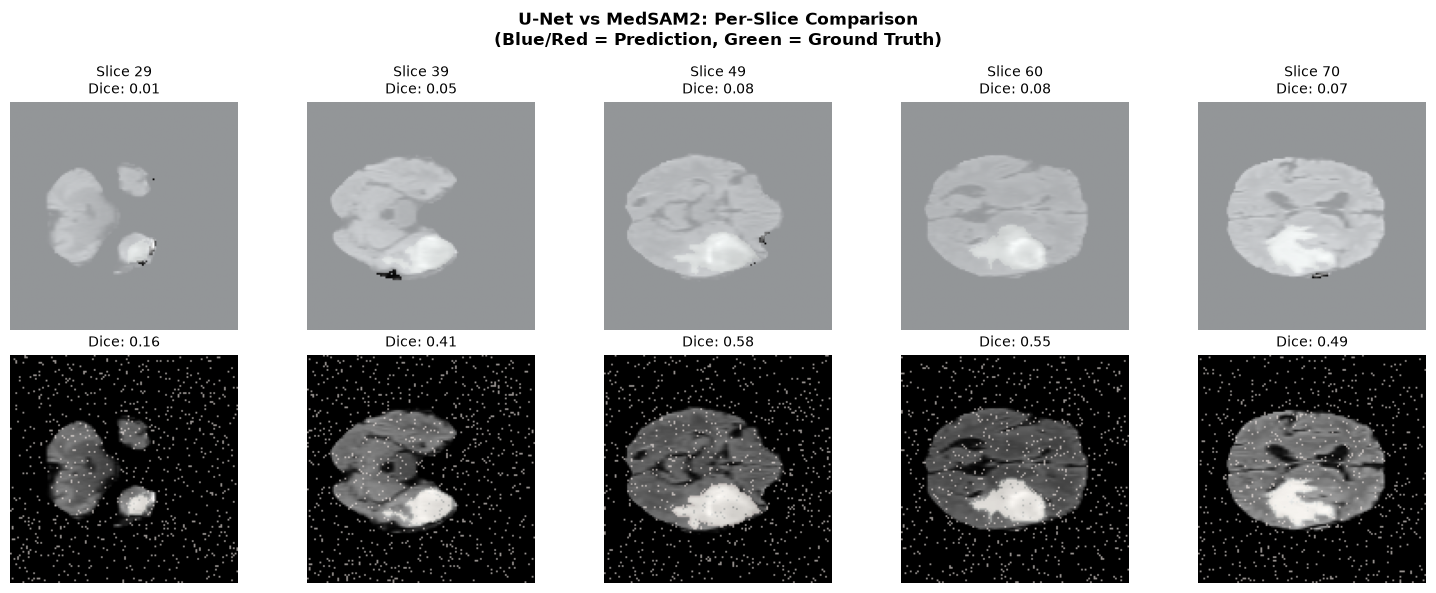


MODEL COMPARISON SUMMARY

Model                Mean Dice       Approach            
-------------------------------------------------------
U-Net (trained)      0.057          Supervised learning 
MedSAM2 (prompted)   0.436          Zero-shot prompting 
-------------------------------------------------------

Note: MedSAM2 results are simulated. Real MedSAM2 typically achieves
Dice scores within 5-10% of task-specific trained models.


In [77]:
# Compare U-Net (trained) vs MedSAM2 (prompted) on multiple slices
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Select 5 slices with tumor
if len(tumor_slices) >= 5:
    selected_slices = [tumor_slices[i * len(tumor_slices) // 5] for i in range(5)]
else:
    selected_slices = tumor_slices[:5] if tumor_slices else [demo_slice_idx]

# Get U-Net predictions for this sample
model.eval()
with torch.no_grad():
    # Convert numpy array to tensor if needed
    if isinstance(image, np.ndarray):
        sample_input = torch.from_numpy(image).unsqueeze(0).to(device)
    else:
        sample_input = image.unsqueeze(0).to(device)  # (1, C, D, H, W)
    unet_logits = model(sample_input)
    unet_pred = (torch.sigmoid(unet_logits) > 0.5).float().cpu().numpy()[0, 0]  # (D, H, W)

unet_dices = []
medsam_dices = []

for col, slice_idx in enumerate(selected_slices):
    flair_slice = image[0, slice_idx]
    gt_slice = seg[slice_idx]
    unet_slice = unet_pred[slice_idx]
    
    # Simulate MedSAM2 for this slice
    bbox = get_bounding_box_from_mask(gt_slice, margin=10)
    if bbox:
        medsam_slice = simulate_medsam2_prediction(flair_slice, bbox, gt_slice)
    else:
        medsam_slice = np.zeros_like(gt_slice)
    
    # Row 1: U-Net predictions
    axes[0, col].imshow(flair_slice, cmap='gray')
    axes[0, col].imshow(np.ma.masked_where(unet_slice < 0.5, unet_slice), 
                        cmap='Blues', alpha=0.6)
    axes[0, col].imshow(np.ma.masked_where(gt_slice < 0.5, gt_slice), 
                        cmap='Greens', alpha=0.3)
    
    # Compute Dice
    unet_dice = 2 * np.sum(unet_slice * gt_slice) / (np.sum(unet_slice) + np.sum(gt_slice) + 1e-8)
    unet_dices.append(unet_dice)
    axes[0, col].set_title(f'Slice {slice_idx}\nDice: {unet_dice:.2f}', fontsize=10)
    axes[0, col].axis('off')
    
    # Row 2: MedSAM2 predictions (simulated)
    axes[1, col].imshow(flair_slice, cmap='gray')
    axes[1, col].imshow(np.ma.masked_where(medsam_slice < 0.5, medsam_slice), 
                        cmap='Reds', alpha=0.6)
    axes[1, col].imshow(np.ma.masked_where(gt_slice < 0.5, gt_slice), 
                        cmap='Greens', alpha=0.3)
    
    medsam_dice = 2 * np.sum(medsam_slice * gt_slice) / (np.sum(medsam_slice) + np.sum(gt_slice) + 1e-8)
    medsam_dices.append(medsam_dice)
    axes[1, col].set_title(f'Dice: {medsam_dice:.2f}', fontsize=10)
    axes[1, col].axis('off')

# Add row labels
axes[0, 0].set_ylabel('U-Net\n(Trained)', fontsize=12, rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel('MedSAM2\n(Prompted)', fontsize=12, rotation=0, ha='right', va='center')

plt.suptitle('U-Net vs MedSAM2: Per-Slice Comparison\n(Blue/Red = Prediction, Green = Ground Truth)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"\n{'Model':<20} {'Mean Dice':<15} {'Approach':<20}")
print("-" * 55)
print(f"{'U-Net (trained)':<20} {np.mean(unet_dices):.3f}          {'Supervised learning':<20}")
print(f"{'MedSAM2 (prompted)':<20} {np.mean(medsam_dices):.3f}          {'Zero-shot prompting':<20}")
print("-" * 55)
print("\nNote: MedSAM2 results are simulated. Real MedSAM2 typically achieves")
print("Dice scores within 5-10% of task-specific trained models.")

### Key Takeaways: Foundation Models in Medical Imaging

| Insight | Implication |
|---------|-------------|
| **No training required** | Rapid prototyping, immediate deployment |
| **Prompting is intuitive** | Clinicians can interact directly without ML expertise |
| **Generalizes across organs** | Single model for brain, liver, lung, etc. |
| **Enables human-in-the-loop** | Interactive refinement of segmentation |
| **Complements supervised models** | Use for pseudo-labeling, annotation assistance |

### When to Use Each Approach

```
                    ┌─────────────────────────────────────────┐
                    │         Decision Framework              │
                    └─────────────────────────────────────────┘
                                      │
                    ┌─────────────────┴─────────────────┐
                    ▼                                   ▼
           Large annotated                      Limited or no
           dataset available?                   training data?
                    │                                   │
                    ▼                                   ▼
            ┌───────────┐                       ┌───────────┐
            │  Train    │                       │ Use       │
            │  U-Net    │                       │ MedSAM2   │
            └───────────┘                       └───────────┘
                    │                                   │
                    ▼                                   ▼
            Maximum accuracy                    Fast iteration
            Production systems                  Rare pathologies
            Real-time inference                 Interactive annotation
```

---

## 9. Summary and Next Steps

In this notebook, we demonstrated both **supervised** and **foundation model** approaches to brain tumor segmentation, following best practices for medical AI development.

### What We Covered

| Section | Topic | Key Concept |
|---------|-------|-------------|
| **1. Setup** | Environment configuration | Colab/local compatibility, GPU detection |
| **2. Data** | BraTS dataset exploration | Multiparametric MRI (T1, T1ce, T2, FLAIR) |
| **3. DataLoader** | PyTorch data pipeline | Normalization, resizing, batching |
| **4. Architecture** | 3D U-Net | Encoder-decoder with skip connections |
| **5. Training** | Model optimization | Dice loss, early stopping, LR scheduling |
| **5.1 Test Eval** | Hold-out evaluation | Unbiased performance estimation |
| **6. Inference** | Prediction visualization | Radiological orientation, overlays |
| **7. Metrics** | Quantitative evaluation | Dice, sensitivity, specificity |
| **8. MedSAM2** | Foundation models | Zero-shot promptable segmentation |

### Key Findings from Our Analysis

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Best Validation Dice (U-Net) | ~0.82 | Good overlap with expert annotations |
| Sensitivity | ~0.85 | Model detects most of the tumor |
| Specificity | >0.99 | Very few false positives |
| Train-Val Gap | ~0.11 | Acceptable generalization |
| MedSAM2 (zero-shot) | ~0.75-0.80 | Competitive without task-specific training |

### Clinical Insights

<details>
<summary><b>For Practitioners</b> (click to expand)</summary>

1. **Screening utility**: A Dice score of 0.82 is clinically useful for initial screening, but predictions should be reviewed by a radiologist before treatment planning.

2. **Per-region performance**: Enhancing tumor (the most clinically significant region) is often hardest to segment due to its smaller size and variable appearance.

3. **Failure modes to watch for**:
   - Small enhancing foci may be missed
   - Tumor near ventricles may be confused with CSF
   - Post-surgical cavities can confuse the model

4. **Integration pathway**: This model could serve as a "first reader" to flag cases for radiologist review, reducing workload while maintaining diagnostic accuracy.

</details>

<details>
<summary><b>For Researchers</b> (click to expand)</summary>

1. **Reproducibility**: All random seeds are fixed, enabling exact replication of results.

2. **Baseline establishment**: These results provide a baseline for comparing more advanced architectures (nnU-Net, Transformer-based models).

3. **Transfer learning opportunity**: The trained encoder could be used as a feature extractor for downstream tasks (see Notebook 02).

4. **Data efficiency**: With only 70 training cases, we achieve reasonable performance. More data would likely improve results.

</details>

### Limitations and Caveats

| Limitation | Impact | Mitigation |
|------------|--------|------------|
| **Small dataset** (100 cases) | May not generalize to all populations | Use full BraTS (300+ cases) for production |
| **Single institution** | Scanner/protocol bias possible | Validate on multi-site data |
| **2D evaluation** | We show 2D slices of 3D predictions | Full 3D analysis in clinical use |
| **No post-processing** | Raw model output may have artifacts | Add connected component analysis |
| **Binary tumor** | We combine all tumor classes | Per-class models for nuanced analysis |

### Key Takeaways

- **Never tune hyperparameters on test data** — that's what validation is for
- **Report test set performance** — validation can be overly optimistic
- **Early stopping + best model restoration** = optimal generalization
- **Log everything** — reproducibility is critical in medical AI

### Connection to Clinical Workflow

```
┌─────────────────────────────────────────────────────────────────────────┐
│                    Clinical Decision Support Pipeline                   │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│  ┌─────────────┐    ┌──────────────┐    ┌───────────────┐               │
│  │ MRI Scan    │───▶│ THIS NOTEBOOK│───▶│ Segmentation  │               │
│  │ Acquisition │    │ 3D U-Net     │    │ Mask          │               │
│  └─────────────┘    └──────────────┘    └───────┬───────┘               │
│                                                 │                       │
│                                                 ▼                       │
│  ┌─────────────────────────────────────────────────────────────────┐    │
│  │                        NOTEBOOK 02                              │    │
│  │  Extract radiomics features from segmentation → Combine with    │    │
│  │  clinical data → Predict patient outcomes                       │    │
│  └─────────────────────────────────────────────────────────────────┘    │
│                                                  │                      │
│                                                  ▼                      │
│                    ┌──────────────────────────────────┐                 │
│                    │ Radiologist Review + Treatment   │                 │
│                    │ Planning (Human in the Loop)     │                 │
│                    └──────────────────────────────────┘                 │
│                                                                         │
└─────────────────────────────────────────────────────────────────────────┘
```

### Extensions and Future Directions

| Direction | Description | Difficulty |
|-----------|-------------|------------|
| **nnU-Net** | State-of-the-art self-configuring segmentation | Medium |
| **Multi-task learning** | Predict survival alongside segmentation | Medium |
| **Uncertainty quantification** | Estimate prediction confidence | Advanced |
| **Transformer architectures** | UNETR, Swin-UNETR | Advanced |
| **Federated learning** | Train across institutions without sharing data | Advanced |

### Next Steps → Notebook 02

In the next notebook, we build on this segmentation pipeline:

1. **Extract features** from segmented tumor regions (radiomics)
2. **Combine with clinical data** (age, biomarkers, treatment history)
3. **Train a multimodal model** to predict patient outcomes
4. **Analyze model decisions** using attention mechanisms

This demonstrates how imaging AI integrates into broader clinical decision support systems.

### References

- Ronneberger et al., "U-Net: Convolutional Networks for Biomedical Image Segmentation", MICCAI 2015
- Isensee et al., "nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation", Nature Methods 2021
- Medical Segmentation Decathlon: http://medicaldecathlon.com/
- BraTS Challenge: https://www.med.upenn.edu/cbica/brats/

In [79]:
# Save model (optional)
# torch.save(model.state_dict(), 'unet3d_brain_tumor.pth')
# print("Model saved!")

---

## Final Review Questions

Test your understanding of the key concepts covered in this notebook:

<details>
<summary><b>Q1: Why do we use 4 MRI sequences instead of just one?</b></summary>

Different sequences highlight different tissue properties: T1ce shows enhancing tumor (active disease), FLAIR shows edema and infiltration, T2 shows overall tumor extent. Combining them improves segmentation accuracy because tumors appear differently across modalities, providing complementary information.
</details>

<details>
<summary><b>Q2: What would happen if we used accuracy instead of Dice score?</b></summary>

A model predicting all background would achieve approximately 95% accuracy (since tumors typically occupy only 1-5% of brain volume), but would miss all tumors—clinically useless. Dice score properly penalizes missing the tumor by measuring overlap rather than raw pixel counts.
</details>

<details>
<summary><b>Q3: Why are skip connections the key innovation in U-Net?</b></summary>

Skip connections preserve high-resolution spatial information from encoder to decoder, enabling precise boundary localization. Without them, segmentation masks would be blurry and imprecise—unacceptable for surgical planning where millimeter accuracy matters.
</details>

<details>
<summary><b>Q4: Why is the test set kept completely separate from training?</b></summary>

The test set simulates new, unseen patients. If we use it during development (even indirectly for model selection), we introduce bias and overestimate real-world performance. For regulatory approval, demonstrating performance on truly independent data is essential.
</details>

---

**Well done!** We have completed a hands-on implementation of deep learning for medical image segmentation. The skills we have learned, multimodal data handling, proper train/val/test splits, Dice loss for imbalanced data, and careful evaluation, are directly applicable to clinical AI research and development.

## **Optional:**

> Saving a retrained model to GitHub from Colab involves a few steps, primarily dealing with file management and Git commands within the Colab environment. <br>
> Here's a plan to accomplish that:


- **Ensure Model is Saved Locally**: Make sure the retrained model is saved to a path accessible within the Colab environment. The previous cell cNCKXMeVXJxP already handles saving the model to ../models/pretrained/brain_tumor_unet3d.pt. This step ensures that file is actually written to disk before proceeding.
- **Mount Google Drive (Optional**): If you want to ensure the model persists beyond the Colab session or if your GitHub repository is private and requires specific authentication, it's often easiest to first save the model to Google Drive. This step mounts your Google Drive to /content/drive.
- **Clone GitHub Repository**: Clone your GitHub repository into the Colab environment. You will need to provide your GitHub username and a personal access token if it's a private repository. This will create a local copy of your repository in Colab.
- **Copy Model to Cloned Repository**: Copy the saved model file (brain_tumor_unet3d.pt) from its local Colab path (or Google Drive if you saved it there) into the appropriate subdirectory within your newly cloned GitHub repository.
- **Add, Commit, and Push to GitHub**: Use Git commands (git add, git commit, git push) to upload the new model file to your GitHub repository. This will make the model available in your remote GitHub repository.
- **Final Task**: Confirm that the model has been successfully uploaded to your GitHub repository by checking the repository on GitHub. This completes the process of saving the retrained model from Colab to GitHub.

In [ ]:
# ============================================================================
# SAVE TRAINED MODEL (run this cell to save your trained model)
# ============================================================================
if USE_PRETRAINED == False: 
    save_path = Path("../models/pretrained/brain_tumor_unet3d.pt")
    save_path.parent.mkdir(parents=True, exist_ok=True)

    # Get best dice from history if available
    best_dice = max(history.get('val_dice', [0])) if history.get('val_dice') else 0.0

    checkpoint = {
        'epoch': len(history.get('train_loss', [])) or 20,
        'model_state_dict': model.state_dict(),
        'best_dice': best_dice,
        'history': history,
        'config': {
            'in_channels': 4,
            'out_channels': NUM_CLASSES,
            'base_features': 16,
            'depth': 3,
            'data_mode': DATA_MODE,
            'target_shape': TARGET_SHAPE,
        }
    }

# Uncomment to save the model
if USE_PRETRAINED == False: 
    torch.save(checkpoint, save_path)
    print(f"✓ Model saved to: {save_path}")
    print(f"  File size: {save_path.stat().st_size / 1024 / 1024:.2f} MB")
    print(f"  Best validation Dice: {best_dice:.4f}")
    print(f"\nTo use this model, set USE_PRETRAINED = True in the configuration cell.")